In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [2]:

df = pd.read_excel("/Users/jaworskj/Desktop/Bnet_thermal_bscans_results/Model_perfomance_small_part_only.xlsx")

In [3]:
df

,Unnamed: 0,Median Signed,Std around median,MAE [mm],MedAE [mm],RMSE [mm],Recall,Median Signed.1,Std around median.1,MAE [mm].1,...,RMSE [mm].6,Recall.6,Median Signed.7,Std around median.7,MAE [mm].7,MedAE [mm].7,RMSE [mm].7,Recall.7,Best IOU,Worst IOU.1
0,H+C no projection,0.250000,NaN,NaN,NaN,NaN,NaN,0.450000,NaN,NaN,...,NaN,NaN,0.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Bnet-Mean H+C,-0.010024,0.030376,0.097794,0.078210,0.144837,0.98,-0.000069,0.020457,0.064973,...,0.109934,0.99,-0.001156,0.014648,0.025135,0.016346,0.072186,0.99,0.91,0.73
2,Bnet-Vertical projection H+C,-0.013200,0.021425,0.062900,0.045735,0.111536,0.98,0.004932,0.023116,0.067756,...,0.116641,0.99,0.004850,0.018864,0.036185,0.026880,0.063388,0.99,0.90,0.61
3,Bnet-Deeper regressor H+C,-0.007632,0.024118,0.077422,0.051318,0.139004,0.96,0.006046,0.023090,0.052607,...,0.080292,0.99,0.000576,0.016160,0.023520,0.014421,0.053466,0.99,0.89,0.60
4,Bnet-End refinement H+C,-0.012668,0.024632,0.104906,0.063558,0.189369,0.94,0.018993,0.025782,0.097867,...,0.074748,0.99,0.004235,0.018764,0.037579,0.024407,0.113963,0.99,0.89,0.68
5,C no projection,0.250000,NaN,NaN,NaN,NaN,NaN,0.450000,NaN,NaN,...,NaN,NaN,0.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Bnet-Mean C,-0.010097,0.024970,0.071231,0.058054,0.106059,0.98,-0.000719,0.024260,0.057506,...,0.096164,0.99,0.013919,0.017871,0.060919,0.053085,0.107663,0.99,0.87,0.64
7,Bnet-Vertical projection C,-0.004602,0.028446,0.082233,0.066176,0.128341,0.98,-0.020789,0.029313,0.101514,...,0.137494,0.99,0.025100,0.017658,0.092680,0.090340,0.113334,0.99,0.84,0.62
8,Bnet-Deeper regressor C,-0.033233,0.026353,0.135375,0.123743,0.189333,0.96,-0.003247,0.023689,0.085250,...,0.113843,0.99,0.008248,0.019291,0.048152,0.043592,0.073966,0.99,0.87,0.68
9,Bnet-End refinement C,-0.030274,0.025241,0.114280,0.100524,0.146120,0.99,-0.008738,0.021581,0.065481,...,0.123942,0.99,-0.006591,0.018125,0.045692,0.030546,0.107660,0.99,0.81,0.62


In [4]:
print(df.columns)

Index(['Unnamed: 0', 'Median Signed', 'Std around median', 'MAE [mm]',
       'MedAE [mm]', 'RMSE [mm]', 'Recall', 'Median Signed.1',
       'Std around median.1', 'MAE [mm].1', 'MedAE [mm].1', 'RMSE [mm].1',
       'Recall.1', 'Median Signed.2', 'Std around median.2', 'MAE [mm].2',
       'MedAE [mm].2', 'RMSE [mm].2', 'Recall.2', 'Median Signed.3',
       'Std around median.3', 'MAE [mm].3', 'MedAE [mm].3', 'RMSE [mm].3',
       'Recall.3', ' Best IOU', 'Worst IOU', 'Median Signed.4',
       'Std around median.4', 'MAE [mm].4', 'MedAE [mm].4', 'RMSE [mm].4',
       'Recall.4', 'Median Signed.5', 'Std around median.5', 'MAE [mm].5',
       'MedAE [mm].5', 'RMSE [mm].5', 'Recall.5', 'Median Signed.6',
       'Std around median.6', 'MAE [mm].6', 'MedAE [mm].6', 'RMSE [mm].6',
       'Recall.6', 'Median Signed.7', 'Std around median.7', 'MAE [mm].7',
       'MedAE [mm].7', 'RMSE [mm].7', 'Recall.7', 'Best IOU', 'Worst IOU.1'],
      dtype='str')


In [5]:
print(df.iloc[:, 0])

0                H+C no projection
1                    Bnet-Mean H+C
2     Bnet-Vertical projection H+C
3        Bnet-Deeper regressor H+C
4          Bnet-End refinement H+C
5                  C no projection
6                      Bnet-Mean C
7       Bnet-Vertical projection C
8          Bnet-Deeper regressor C
9            Bnet-End refinement C
10           H+C cosine projection
11                   Bnet-Mean H+C
12    Bnet-Vertical projection H+C
13       Bnet-Deeper regressor H+C
14         Bnet-End refinement H+C
15             C cosine projection
16                     Bnet-Mean C
17      Bnet-Vertical projection C
18         Bnet-Deeper regressor C
19           Bnet-End refinement C
20            H+C log1p projection
21                   Bnet-Mean H+C
22    Bnet-Vertical projection H+C
23       Bnet-Deeper regressor H+C
24         Bnet-End refinement H+C
25              C log1p projection
26                     Bnet-Mean C
27      Bnet-Vertical projection C
28         Bnet-Deep

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Exact column names from the Excel file
val_best_col = " Best IOU"
val_worst_col = "Worst IOU"

test_best_col = "Best IOU"
test_worst_col = "Worst IOU.1"

iou_columns = [
    val_best_col,
    val_worst_col,
    test_best_col,
    test_worst_col
]

df[iou_columns] = df[iou_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

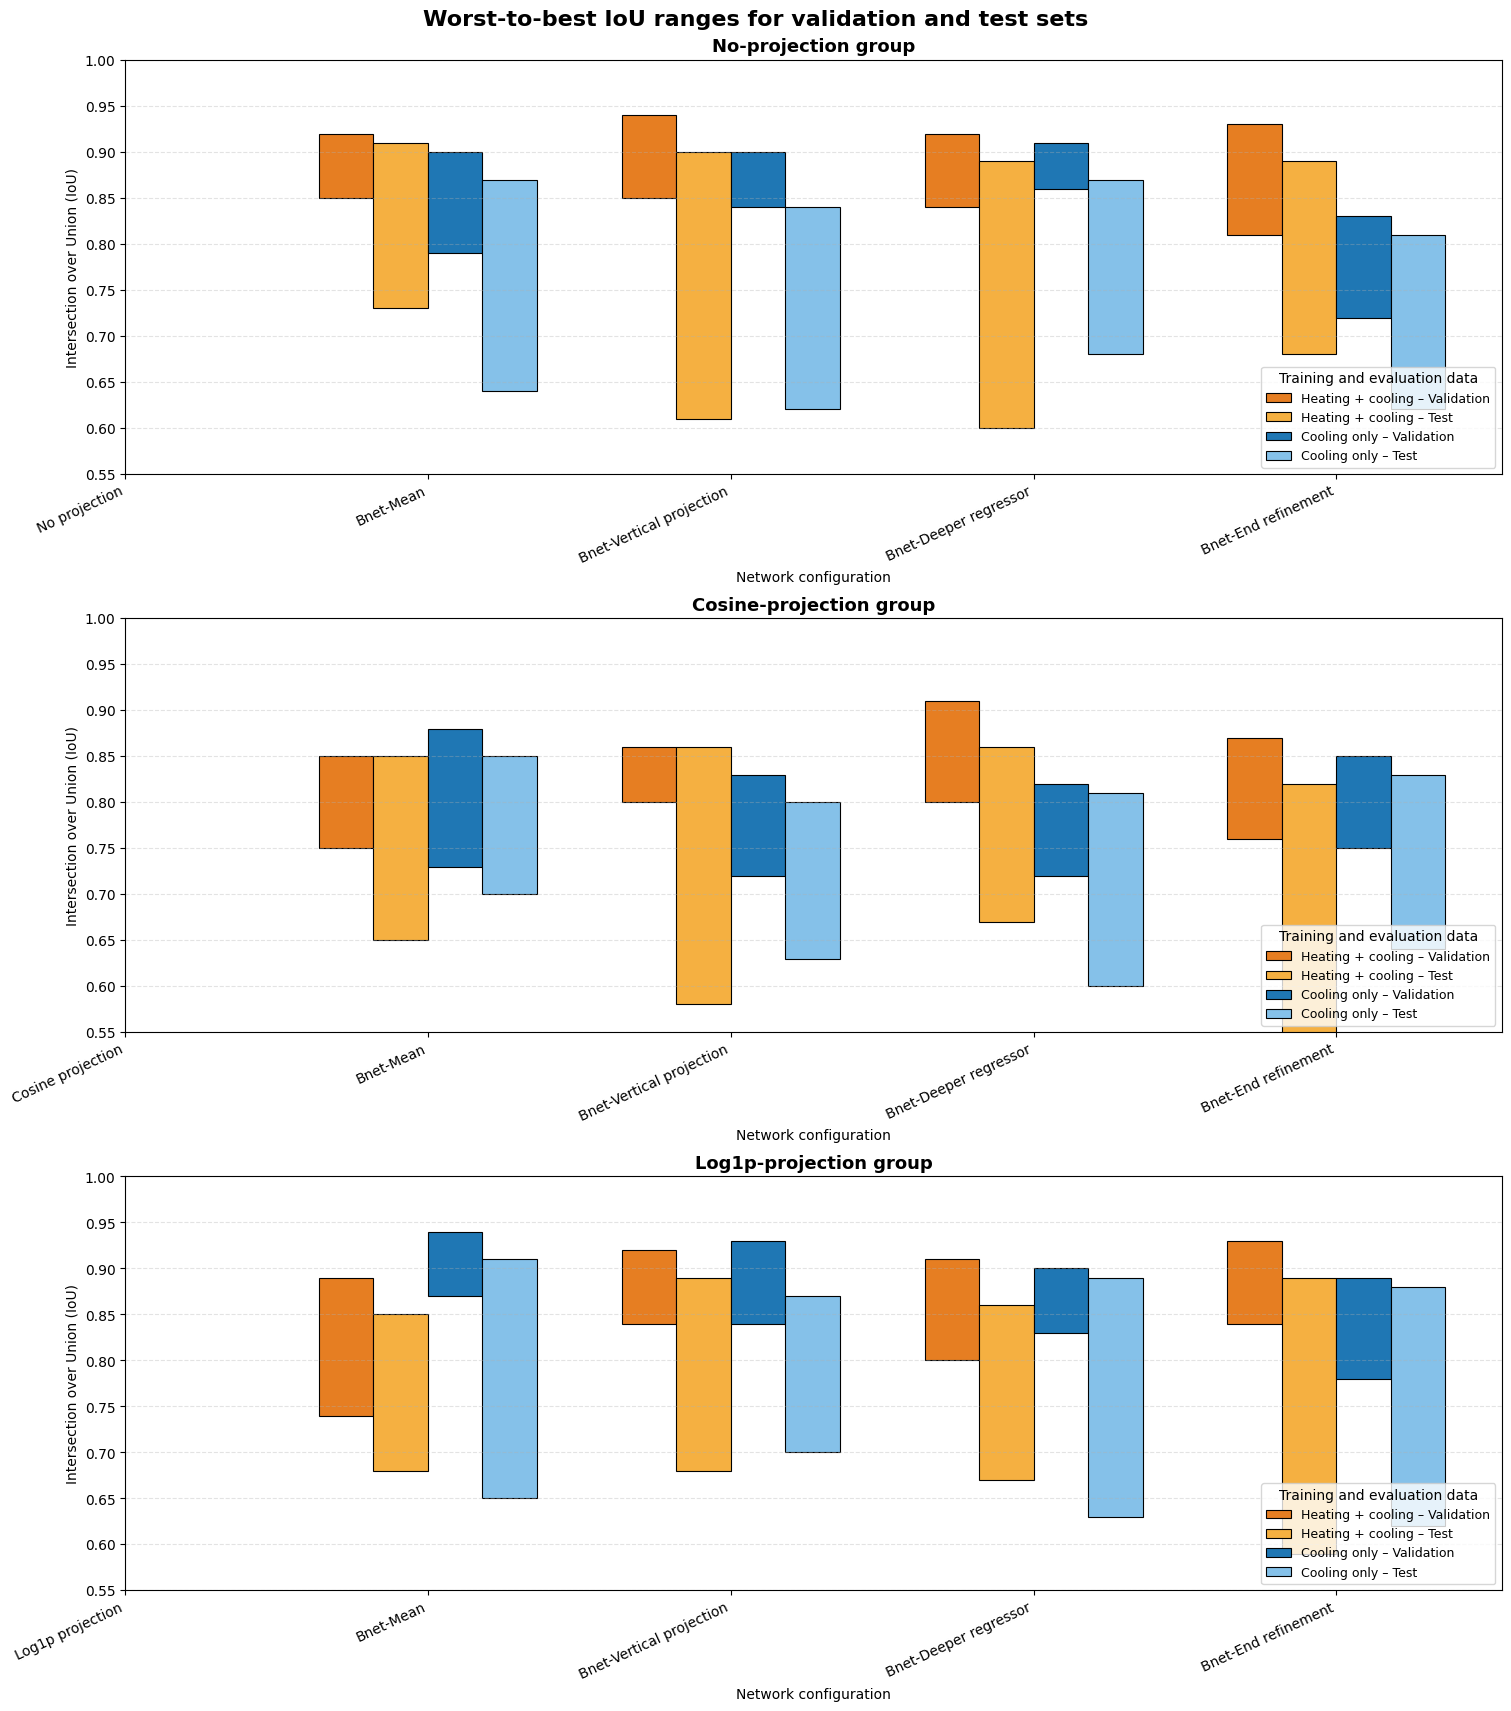

In [10]:
# Each block contains five H+C configurations,
# followed by the same five cooling-only configurations
plot_groups = [
    {
        "title": "No-projection group",
        "start": 0,
        "labels": [
            "No projection",
            "Bnet-Mean",
            "Bnet-Vertical projection",
            "Bnet-Deeper regressor",
            "Bnet-End refinement"
        ]
    },
    {
        "title": "Cosine-projection group",
        "start": 10,
        "labels": [
            "Cosine projection",
            "Bnet-Mean",
            "Bnet-Vertical projection",
            "Bnet-Deeper regressor",
            "Bnet-End refinement"
        ]
    },
    {
        "title": "Log1p-projection group",
        "start": 20,
        "labels": [
            "Log1p projection",
            "Bnet-Mean",
            "Bnet-Vertical projection",
            "Bnet-Deeper regressor",
            "Bnet-End refinement"
        ]
    }
]

fig, axes = plt.subplots(
    3, 1,
    figsize=(15, 17),
    constrained_layout=True
)

bar_width = 0.18

# Orange: heating + cooling
# Blue: cooling only
styles = {
    "H+C validation": {
        "offset": -1.5 * bar_width,
        "color": "#e67e22"
    },
    "H+C test": {
        "offset": -0.5 * bar_width,
        "color": "#f5b041"
    },
    "C validation": {
        "offset": 0.5 * bar_width,
        "color": "#1f77b4"
    },
    "C test": {
        "offset": 1.5 * bar_width,
        "color": "#85c1e9"
    }
}


def plot_vertical_range(
    ax,
    x,
    worst,
    best,
    offset,
    color,
    label
):
    """Draw a vertical box extending from worst to best IoU."""

    low = np.minimum(worst, best)
    high = np.maximum(worst, best)

    ax.bar(
        x + offset,
        height=high - low,
        bottom=low,
        width=bar_width,
        color=color,
        edgecolor="black",
        linewidth=0.8,
        label=label
    )


for ax, group in zip(axes, plot_groups):

    start = group["start"]

    # First five rows: heating and cooling
    hc_data = df.iloc[start:start + 5]

    # Following five rows: cooling only
    c_data = df.iloc[start + 5:start + 10]

    x = np.arange(5)

    # Heating + cooling: validation
    plot_vertical_range(
        ax,
        x,
        hc_data[val_worst_col].to_numpy(dtype=float),
        hc_data[val_best_col].to_numpy(dtype=float),
        styles["H+C validation"]["offset"],
        styles["H+C validation"]["color"],
        "Heating + cooling – Validation"
    )

    # Heating + cooling: test
    plot_vertical_range(
        ax,
        x,
        hc_data[test_worst_col].to_numpy(dtype=float),
        hc_data[test_best_col].to_numpy(dtype=float),
        styles["H+C test"]["offset"],
        styles["H+C test"]["color"],
        "Heating + cooling – Test"
    )

    # Cooling only: validation
    plot_vertical_range(
        ax,
        x,
        c_data[val_worst_col].to_numpy(dtype=float),
        c_data[val_best_col].to_numpy(dtype=float),
        styles["C validation"]["offset"],
        styles["C validation"]["color"],
        "Cooling only – Validation"
    )

    # Cooling only: test
    plot_vertical_range(
        ax,
        x,
        c_data[test_worst_col].to_numpy(dtype=float),
        c_data[test_best_col].to_numpy(dtype=float),
        styles["C test"]["offset"],
        styles["C test"]["color"],
        "Cooling only – Test"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        group["labels"],
        rotation=25,
        ha="right"
    )

    ax.set_ylim(0.55, 1.00)
    ax.set_ylabel("Intersection over Union (IoU)")
    ax.set_xlabel("Network configuration")
    ax.set_title(
        group["title"],
        fontsize=13,
        fontweight="bold"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.35
    )

    ax.legend(
        title="Training and evaluation data",
        loc="lower right",
        fontsize=9
    )

fig.suptitle(
    "Worst-to-best IoU ranges for validation and test sets",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Exact column names
val_best_col = " Best IOU"
val_worst_col = "Worst IOU"
test_best_col = "Best IOU"
test_worst_col = "Worst IOU.1"

# Rows belonging to each training configuration
hc_indices = np.r_[0:5, 10:15, 20:25]
c_indices = np.r_[5:10, 15:20, 25:30]

hc_data = df.iloc[hc_indices].copy()
c_data = df.iloc[c_indices].copy()

# Labels distinguish repeated architectures between projection groups
configuration_labels = [
    "No projection",
    "No projection\nBnet-Mean",
    "No projection\nVertical projection",
    "No projection\nDeeper regressor",
    "No projection\nEnd refinement",

    "Cosine projection",
    "Cosine\nBnet-Mean",
    "Cosine\nVertical projection",
    "Cosine\nDeeper regressor",
    "Cosine\nEnd refinement",

    "Log1p projection",
    "Log1p\nBnet-Mean",
    "Log1p\nVertical projection",
    "Log1p\nDeeper regressor",
    "Log1p\nEnd refinement"
]

x = np.arange(len(configuration_labels))

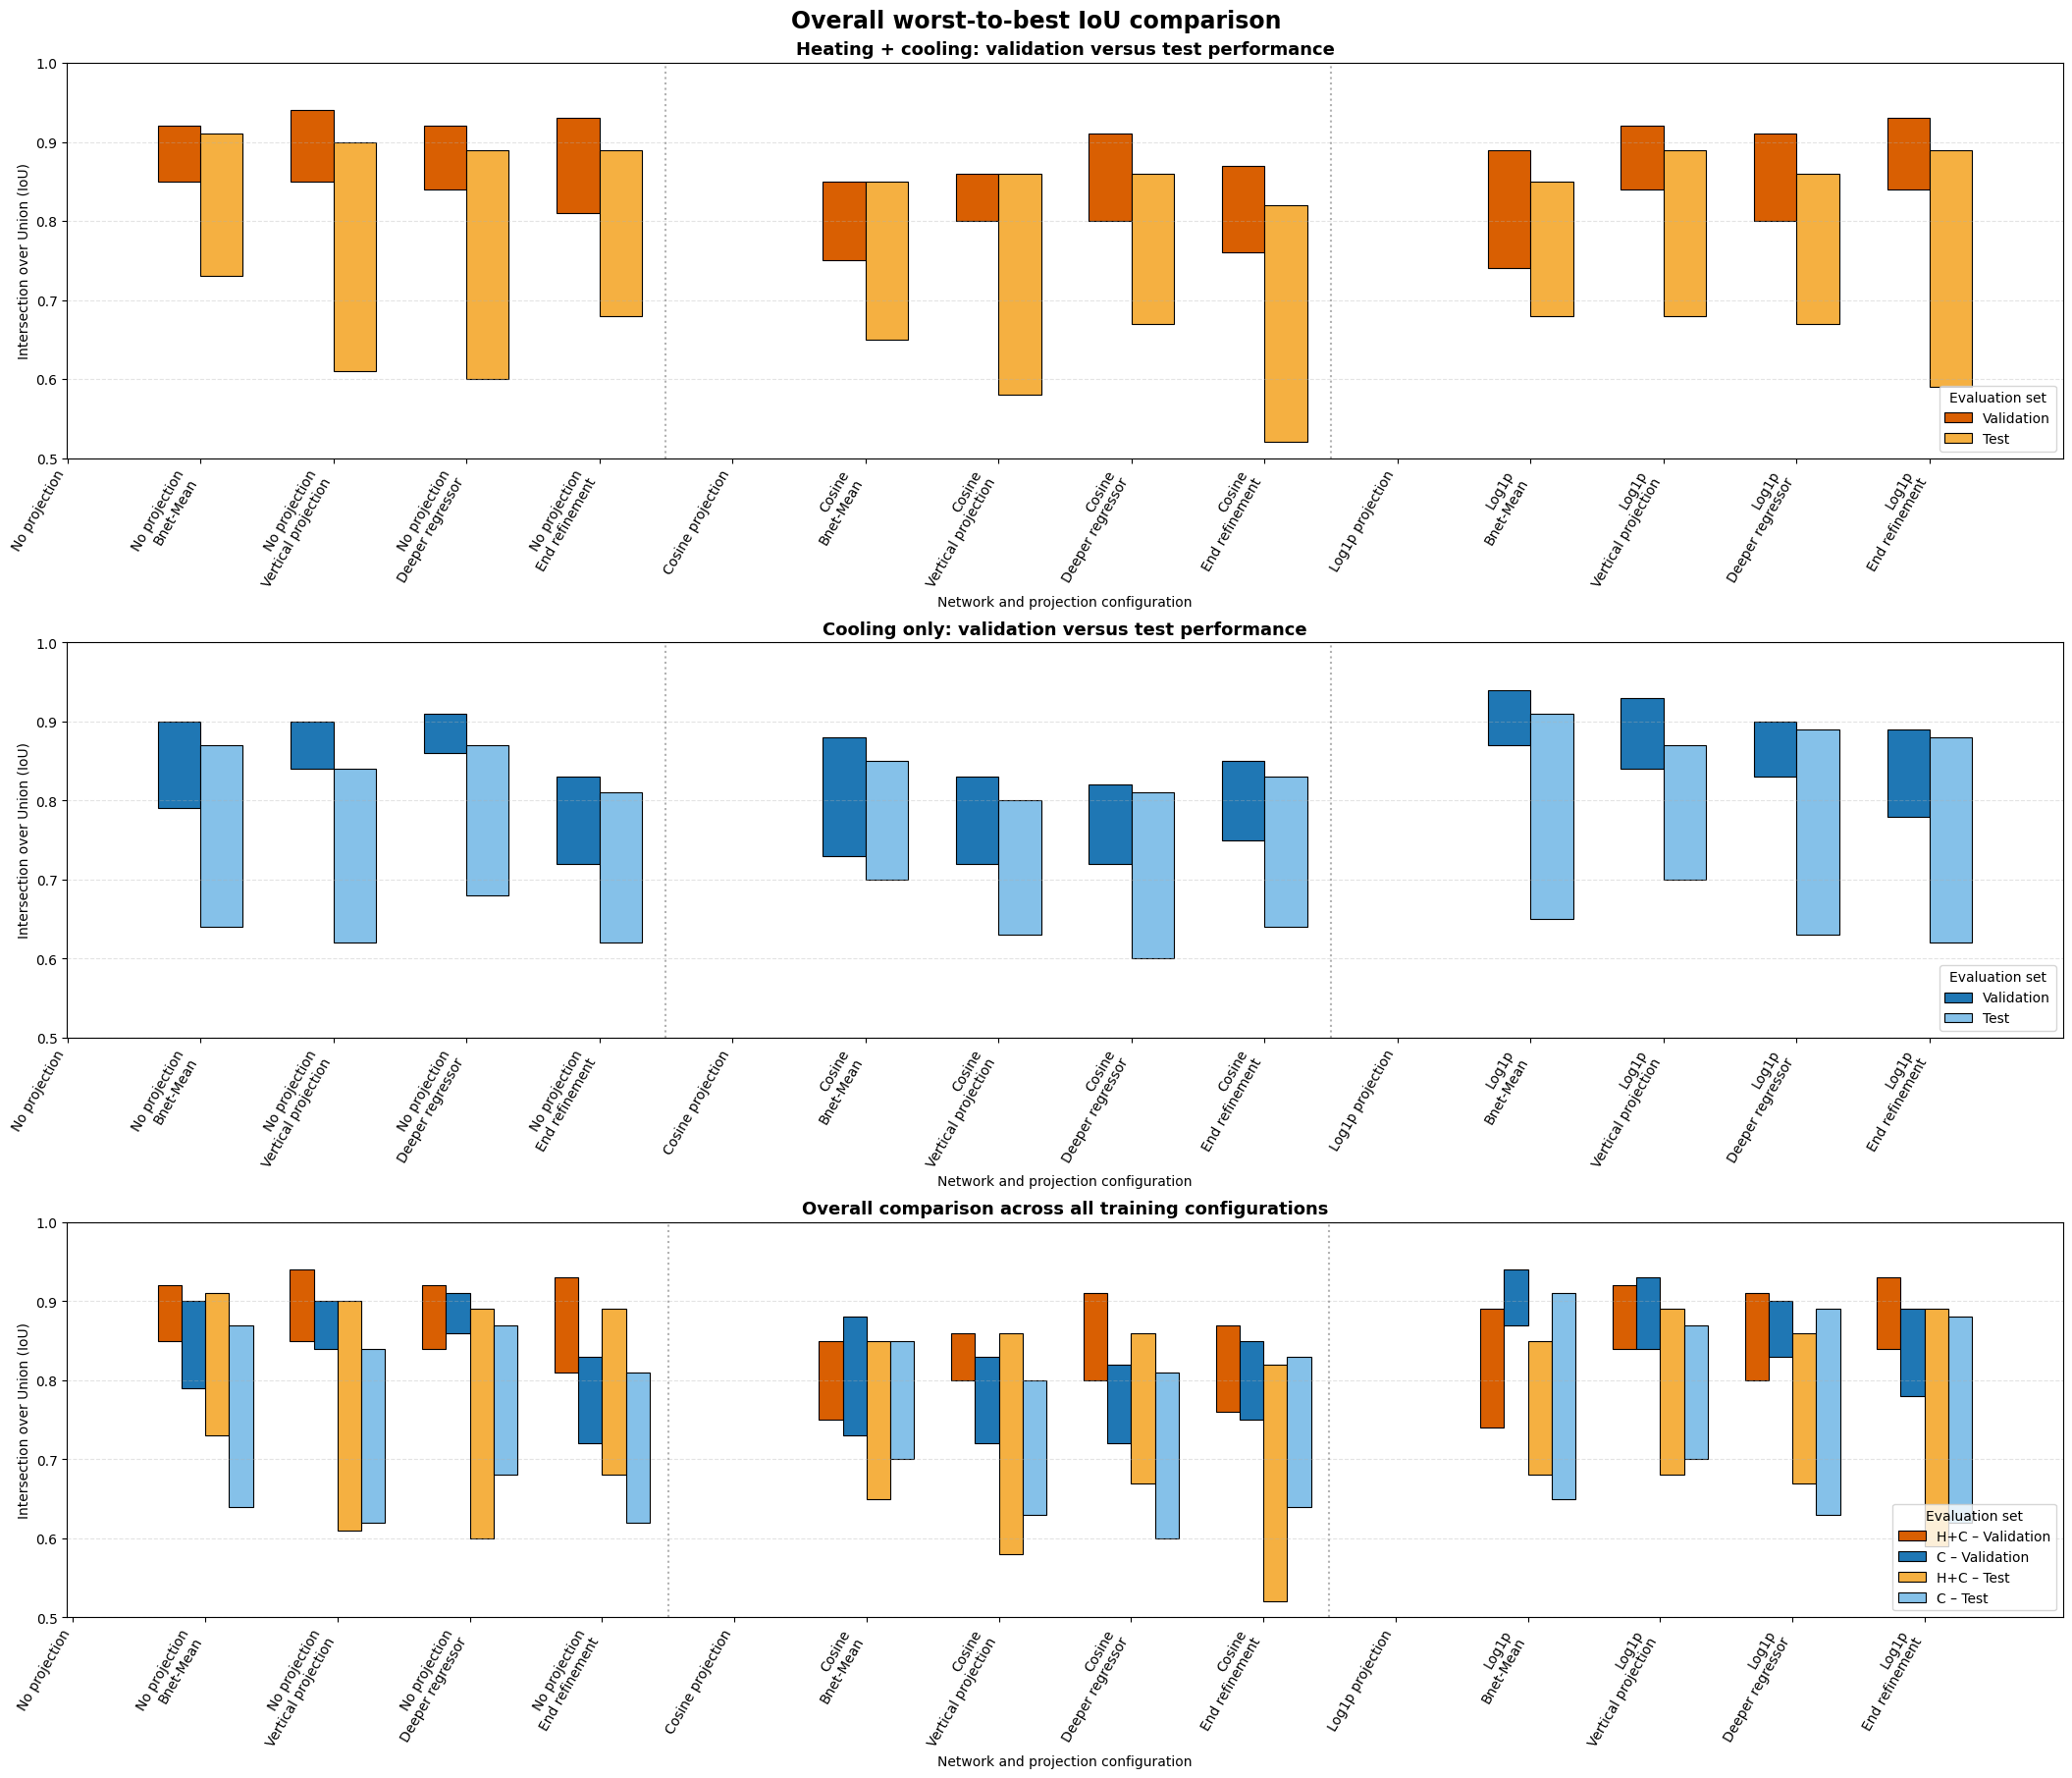

In [17]:
def draw_iou_range(
    ax,
    x_positions,
    worst,
    best,
    offset,
    width,
    color,
    label
):
    """Draw vertical boxes extending from worst to best IoU."""

    low = np.minimum(worst, best)
    high = np.maximum(worst, best)

    ax.bar(
        x_positions + offset,
        height=high - low,
        bottom=low,
        width=width,
        color=color,
        edgecolor="black",
        linewidth=0.8,
        label=label
    )


def format_axis(ax, title):
    ax.set_xticks(x)
    ax.set_xticklabels(
        configuration_labels,
        rotation=60,
        ha="right"
    )

    ax.set_ylim(0.5, 1.00)
    ax.set_xlabel("Network and projection configuration")
    ax.set_ylabel("Intersection over Union (IoU)")
    ax.set_title(title, fontsize=13, fontweight="bold")

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.35
    )

    # Separate the three projection groups
    ax.axvline(4.5, color="grey", linestyle=":", alpha=0.6)
    ax.axvline(9.5, color="grey", linestyle=":", alpha=0.6)

    ax.legend(
        title="Evaluation set",
        loc="lower right"
    )

fig, axes = plt.subplots(
    3, 1,
    figsize=(21, 18),
    constrained_layout=True
)

# Colours
hc_validation_color = "#d95f02"   # Dark orange
hc_test_color = "#f5b041"         # Light orange

c_validation_color = "#1f77b4"    # Dark blue
c_test_color = "#85c1e9"          # Light blue


width = 0.32

draw_iou_range(
    axes[0],
    x,
    hc_data[val_worst_col].to_numpy(dtype=float),
    hc_data[val_best_col].to_numpy(dtype=float),
    offset=-width / 2,
    width=width,
    color=hc_validation_color,
    label="Validation"
)

draw_iou_range(
    axes[0],
    x,
    hc_data[test_worst_col].to_numpy(dtype=float),
    hc_data[test_best_col].to_numpy(dtype=float),
    offset=width / 2,
    width=width,
    color=hc_test_color,
    label="Test"
)

format_axis(
    axes[0],
    "Heating + cooling: validation versus test performance"
)

draw_iou_range(
    axes[1],
    x,
    c_data[val_worst_col].to_numpy(dtype=float),
    c_data[val_best_col].to_numpy(dtype=float),
    offset=-width / 2,
    width=width,
    color=c_validation_color,
    label="Validation"
)

draw_iou_range(
    axes[1],
    x,
    c_data[test_worst_col].to_numpy(dtype=float),
    c_data[test_best_col].to_numpy(dtype=float),
    offset=width / 2,
    width=width,
    color=c_test_color,
    label="Test"
)

format_axis(
    axes[1],
    "Cooling only: validation versus test performance"
)

overall_width = 0.18

draw_iou_range(
    axes[2],
    x,
    hc_data[val_worst_col].to_numpy(dtype=float),
    hc_data[val_best_col].to_numpy(dtype=float),
    offset=-1.5 * overall_width,
    width=overall_width,
    color=hc_validation_color,
    label="H+C – Validation"
)

draw_iou_range(
    axes[2],
    x,
    c_data[val_worst_col].to_numpy(dtype=float),
    c_data[val_best_col].to_numpy(dtype=float),
    offset=-0.5 * overall_width,
    width=overall_width,
    color=c_validation_color,
    label="C – Validation"
)

draw_iou_range(
    axes[2],
    x,
    hc_data[test_worst_col].to_numpy(dtype=float),
    hc_data[test_best_col].to_numpy(dtype=float),
    offset=0.5 * overall_width,
    width=overall_width,
    color=hc_test_color,
    label="H+C – Test"
)

draw_iou_range(
    axes[2],
    x,
    c_data[test_worst_col].to_numpy(dtype=float),
    c_data[test_best_col].to_numpy(dtype=float),
    offset=1.5 * overall_width,
    width=overall_width,
    color=c_test_color,
    label="C – Test"
)

format_axis(
    axes[2],
    "Overall comparison across all training configurations"
)

fig.suptitle(
    "Overall worst-to-best IoU comparison",
    fontsize=17,
    fontweight="bold"
)

plt.show()

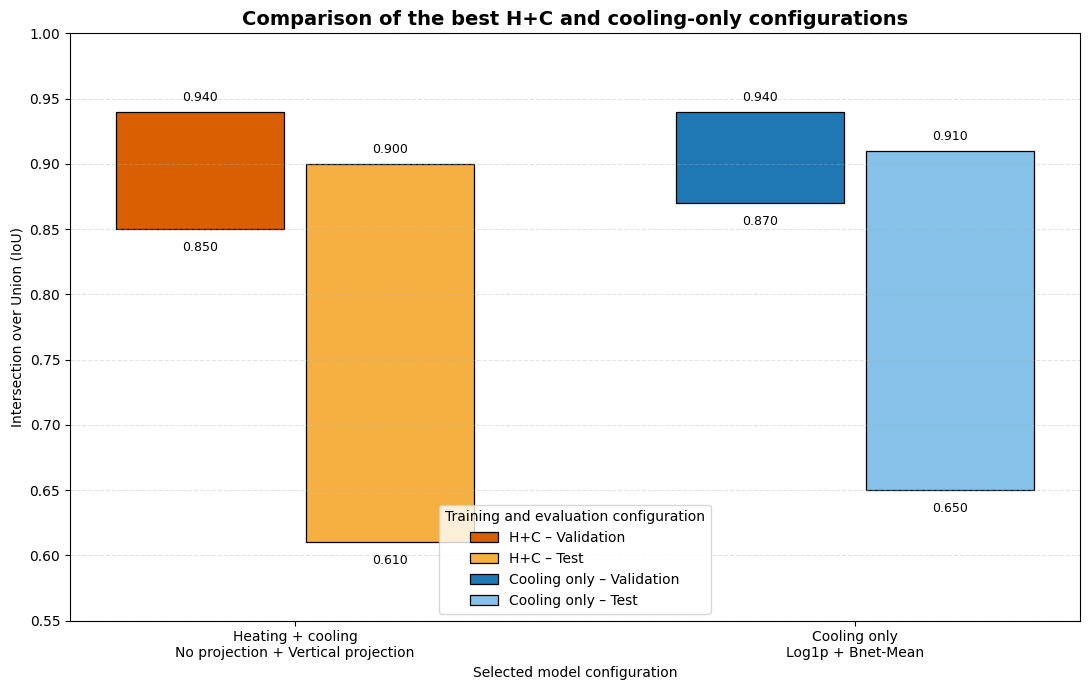

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

val_best_col = " Best IOU"
val_worst_col = "Worst IOU"
test_best_col = "Best IOU"
test_worst_col = "Worst IOU.1"

# Selected candidates
hc_index = 2   # H+C, no projection, vertical projection
c_index = 26   # Cooling only, log1p, Bnet-Mean

hc_model = df.iloc[hc_index]
c_model = df.iloc[c_index]

model_labels = [
    "Heating + cooling\nNo projection + Vertical projection",
    "Cooling only\nLog1p + Bnet-Mean"
]

def draw_selected_range(
    ax,
    x_position,
    row,
    worst_column,
    best_column,
    width,
    color,
    label
):
    worst = float(row[worst_column])
    best = float(row[best_column])

    low = min(worst, best)
    high = max(worst, best)

    ax.bar(
        x_position,
        height=high - low,
        bottom=low,
        width=width,
        color=color,
        edgecolor="black",
        linewidth=0.9,
        label=label
    )

    # Display exact worst and best values
    ax.text(
        x_position,
        high + 0.006,
        f"{high:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

    ax.text(
        x_position,
        low - 0.009,
        f"{low:.3f}",
        ha="center",
        va="top",
        fontsize=9
    )

fig, ax = plt.subplots(figsize=(11, 7))

x = np.arange(2)
bar_width = 0.30
offset = 0.17

# H+C candidate: orange
draw_selected_range(
    ax,
    x[0] - offset,
    hc_model,
    val_worst_col,
    val_best_col,
    bar_width,
    "#d95f02",
    "H+C – Validation"
)

draw_selected_range(
    ax,
    x[0] + offset,
    hc_model,
    test_worst_col,
    test_best_col,
    bar_width,
    "#f5b041",
    "H+C – Test"
)

# Cooling-only candidate: blue
draw_selected_range(
    ax,
    x[1] - offset,
    c_model,
    val_worst_col,
    val_best_col,
    bar_width,
    "#1f77b4",
    "Cooling only – Validation"
)

draw_selected_range(
    ax,
    x[1] + offset,
    c_model,
    test_worst_col,
    test_best_col,
    bar_width,
    "#85c1e9",
    "Cooling only – Test"
)

ax.set_xticks(x)
ax.set_xticklabels(model_labels)

ax.set_ylim(0.55, 1.00)
ax.set_ylabel("Intersection over Union (IoU)")
ax.set_xlabel("Selected model configuration")

ax.set_title(
    "Comparison of the best H+C and cooling-only configurations",
    fontsize=14,
    fontweight="bold"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.legend(
    title="Training and evaluation configuration",
    loc="lower center"
)

plt.tight_layout()
plt.show()



In [19]:
comparison = pd.DataFrame({
    "Configuration": model_labels,

    "Validation worst": [
        hc_model[val_worst_col],
        c_model[val_worst_col]
    ],

    "Validation best": [
        hc_model[val_best_col],
        c_model[val_best_col]
    ],

    "Test worst": [
        hc_model[test_worst_col],
        c_model[test_worst_col]
    ],

    "Test best": [
        hc_model[test_best_col],
        c_model[test_best_col]
    ]
})

comparison["Validation midpoint"] = (
    comparison["Validation worst"] +
    comparison["Validation best"]
) / 2

comparison["Test midpoint"] = (
    comparison["Test worst"] +
    comparison["Test best"]
) / 2

print(comparison.round(3))

                                       Configuration  Validation worst  \
0  Heating + cooling\nNo projection + Vertical pr...              0.85   
1                    Cooling only\nLog1p + Bnet-Mean              0.87   

   Validation best  Test worst  Test best  Validation midpoint  Test midpoint  
0             0.94        0.61       0.90                0.895          0.755  
1             0.94        0.65       0.91                0.905          0.780  


In [22]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

print(df.iloc[:3].T.to_string())

                                     0              1                             2
Unnamed: 0           H+C no projection  Bnet-Mean H+C  Bnet-Vertical projection H+C
Median Signed                     0.25      -0.010024                       -0.0132
Std around median                  NaN       0.030376                      0.021425
MAE [mm]                           NaN       0.097794                        0.0629
MedAE [mm]                         NaN        0.07821                      0.045735
RMSE [mm]                          NaN       0.144837                      0.111536
Recall                             NaN           0.98                          0.98
Median Signed.1                   0.45      -0.000069                      0.004932
Std around median.1                NaN       0.020457                      0.023116
MAE [mm].1                         NaN       0.064973                      0.067756
MedAE [mm].1                       NaN       0.035461                      0

In [27]:
# ============================================================
# 1. IMPORTS AND DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

# Uncomment and change the filename if df is not loaded yet:
# df = pd.read_excel("your_file.xlsx")

In [28]:
# ============================================================
# 2. DEFINE ACTUAL MODEL ROWS
# ============================================================

# Architecture code and full name
architectures = [
    ("M", "Bnet-Mean"),
    ("V", "Bnet-Vertical projection"),
    ("D", "Bnet-Deeper regressor"),
    ("E", "Bnet-End refinement")
]

# Rows 0, 5, 10, 15, 20 and 25 contain configuration/depth
# information and are therefore not models.
projection_blocks = [
    {
        "code": "NP",
        "name": "No projection",
        "hc_start": 1,
        "c_start": 6
    },
    {
        "code": "COS",
        "name": "Cosine projection",
        "hc_start": 11,
        "c_start": 16
    },
    {
        "code": "L1",
        "name": "Log1p projection",
        "hc_start": 21,
        "c_start": 26
    }
]

model_records = []

for block in projection_blocks:

    training_groups = [
        ("H+C", "HC", block["hc_start"]),
        ("Cooling only", "C", block["c_start"])
    ]

    for training_name, training_code, start_row in training_groups:

        for offset, (architecture_code, architecture_name) in enumerate(
            architectures
        ):
            model_records.append({
                "row": start_row + offset,
                "code": (
                    f"{training_code}-"
                    f"{block['code']}-"
                    f"{architecture_code}"
                ),
                "training": training_name,
                "projection": block["name"],
                "projection_code": block["code"],
                "architecture": architecture_name,
                "architecture_code": architecture_code
            })

model_info = pd.DataFrame(model_records)

print("Models included in the analysis:\n")

print(
    model_info[
        [
            "code",
            "row",
            "training",
            "projection",
            "architecture"
        ]
    ].to_string(index=False)
)

Models included in the analysis:

    code  row     training        projection             architecture
 HC-NP-M    1          H+C     No projection                Bnet-Mean
 HC-NP-V    2          H+C     No projection Bnet-Vertical projection
 HC-NP-D    3          H+C     No projection    Bnet-Deeper regressor
 HC-NP-E    4          H+C     No projection      Bnet-End refinement
  C-NP-M    6 Cooling only     No projection                Bnet-Mean
  C-NP-V    7 Cooling only     No projection Bnet-Vertical projection
  C-NP-D    8 Cooling only     No projection    Bnet-Deeper regressor
  C-NP-E    9 Cooling only     No projection      Bnet-End refinement
HC-COS-M   11          H+C Cosine projection                Bnet-Mean
HC-COS-V   12          H+C Cosine projection Bnet-Vertical projection
HC-COS-D   13          H+C Cosine projection    Bnet-Deeper regressor
HC-COS-E   14          H+C Cosine projection      Bnet-End refinement
 C-COS-M   16 Cooling only Cosine projection            

In [29]:
# ============================================================
# 3. DEFINE VALIDATION AND TEST DEPTHS
# ============================================================

depth_specs = []

for i in range(8):

    suffix = "" if i == 0 else f".{i}"

    signed_column = f"Median Signed{suffix}"
    std_column = f"Std around median{suffix}"

    # First four depths belong to validation;
    # following four belong to test.
    split = "Validation" if i < 4 else "Test"

    # Depth values are stored in the first configuration row
    depth = pd.to_numeric(
        df.iloc[0][signed_column],
        errors="coerce"
    )

    depth_specs.append({
        "depth": float(depth),
        "split": split,
        "signed_column": signed_column,
        "std_column": std_column
    })

depth_table = pd.DataFrame(depth_specs)

print("\nDepth mapping:\n")
print(depth_table.to_string(index=False))


Depth mapping:

 depth      split   signed_column          std_column
  0.25 Validation   Median Signed   Std around median
  0.45 Validation Median Signed.1 Std around median.1
  0.65 Validation Median Signed.2 Std around median.2
  0.85 Validation Median Signed.3 Std around median.3
  0.15       Test Median Signed.4 Std around median.4
  0.35       Test Median Signed.5 Std around median.5
  0.55       Test Median Signed.6 Std around median.6
  0.75       Test Median Signed.7 Std around median.7


In [30]:
# ============================================================
# 4. VISUAL ENCODING
# ============================================================

# Orange = heating and cooling
# Blue = cooling only
training_colors = {
    "H+C": "#d95f02",
    "Cooling only": "#1f77b4"
}

# Marker shape represents the projection configuration
projection_markers = {
    "NP": "o",     # Circle: no projection
    "COS": "s",    # Square: cosine
    "L1": "D"      # Diamond: log1p
}

actual_rows = model_info["row"].tolist()

In [31]:
# ============================================================
# 5. CALCULATE COMMON AXIS LIMITS
# ============================================================

# Common limits allow direct comparison between every depth
all_signed_values = []
all_std_values = []

for spec in depth_specs:

    signed_values = pd.to_numeric(
        df.iloc[actual_rows][spec["signed_column"]],
        errors="coerce"
    ).dropna()

    std_values = pd.to_numeric(
        df.iloc[actual_rows][spec["std_column"]],
        errors="coerce"
    ).dropna()

    all_signed_values.extend(signed_values.tolist())
    all_std_values.extend(std_values.tolist())

signed_limit = max(
    abs(np.nanmin(all_signed_values)),
    abs(np.nanmax(all_signed_values))
) * 1.15

std_limit = np.nanmax(all_std_values) * 1.15

print("\nPlot limits:")
print(f"Signed median: {-signed_limit:.4f} to {signed_limit:.4f}")
print(f"Standard deviation: 0 to {std_limit:.4f}")


Plot limits:
Signed median: -0.0490 to 0.0490
Standard deviation: 0 to 0.0666


In [32]:
# ============================================================
# 6. COMMON LEGEND
# ============================================================

legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="#d95f02",
        markeredgecolor="black",
        markersize=9,
        label="Heating + cooling"
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="#1f77b4",
        markeredgecolor="black",
        markersize=9,
        label="Cooling only"
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=9,
        label="No projection"
    ),
    Line2D(
        [0], [0],
        marker="s",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=9,
        label="Cosine projection"
    ),
    Line2D(
        [0], [0],
        marker="D",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=9,
        label="Log1p projection"
    ),
    Line2D(
        [0], [0],
        marker="*",
        linestyle="none",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=11,
        label="Ideal point"
    )
]

In [33]:
# ============================================================
# 7. FUNCTION FOR ONE VALIDATION OR TEST FIGURE
# ============================================================

def plot_depth_split(split_name):

    selected_specs = [
        spec for spec in depth_specs
        if spec["split"] == split_name
    ]

    fig, axes = plt.subplots(
        nrows=1,
        ncols=4,
        figsize=(24, 7),
        sharex=True,
        sharey=True
    )

    for ax, spec in zip(axes, selected_specs):

        for _, model in model_info.iterrows():

            row = int(model["row"])

            signed_median = pd.to_numeric(
                df.iloc[row][spec["signed_column"]],
                errors="coerce"
            )

            std_median = pd.to_numeric(
                df.iloc[row][spec["std_column"]],
                errors="coerce"
            )

            if pd.isna(signed_median) or pd.isna(std_median):
                continue

            training_group = model["training"]
            projection_code = model["projection_code"]
            architecture_code = model["architecture_code"]

            # Scatter point
            ax.scatter(
                signed_median,
                std_median,
                s=125,
                marker=projection_markers[projection_code],
                color=training_colors[training_group],
                edgecolor="black",
                linewidth=0.7,
                alpha=0.90,
                zorder=3
            )

            # Architecture letter inside the point
            ax.text(
                signed_median,
                std_median,
                architecture_code,
                color="white",
                fontsize=6.5,
                fontweight="bold",
                ha="center",
                va="center",
                zorder=4
            )

        # Signed-median zero line
        ax.axvline(
            0,
            color="black",
            linewidth=1.0,
            zorder=1
        )

        # Standard-deviation zero line
        ax.axhline(
            0,
            color="black",
            linewidth=1.0,
            zorder=1
        )

        # Ideal result: zero bias and zero dispersion
        ax.scatter(
            0,
            0,
            marker="*",
            s=150,
            color="black",
            zorder=5
        )

        ax.set_xlim(-signed_limit, signed_limit)
        ax.set_ylim(-0.002, std_limit)

        ax.grid(
            linestyle="--",
            alpha=0.25
        )

        ax.set_title(
            f"{spec['depth'] * 100:.0f}% removed material",
            fontsize=12,
            fontweight="bold",
            pad=10
        )

    # Shared axis labels
    fig.supxlabel(
        "Signed median error: negative ← 0 → positive",
        fontsize=12,
        y=0.055
    )

    fig.supylabel(
        "Standard deviation around median",
        fontsize=12,
        x=0.012
    )

    # Main title
    fig.suptitle(
        f"{split_name} set: model bias and dispersion by defect depth",
        fontsize=17,
        fontweight="bold",
        y=0.98
    )

    # Legend above plots
    fig.legend(
        handles=legend_elements,
        loc="upper center",
        ncol=6,
        bbox_to_anchor=(0.5, 0.91),
        frameon=True
    )

    # Architecture explanation below legend
    fig.text(
        0.5,
        0.835,
        "Letters inside markers: "
        "M = Bnet-Mean    |    "
        "V = Vertical projection    |    "
        "D = Deeper regressor    |    "
        "E = End refinement",
        ha="center",
        fontsize=10
    )

    # Manual spacing prevents overlaps
    fig.subplots_adjust(
        left=0.055,
        right=0.985,
        bottom=0.15,
        top=0.77,
        wspace=0.20
    )

    return fig

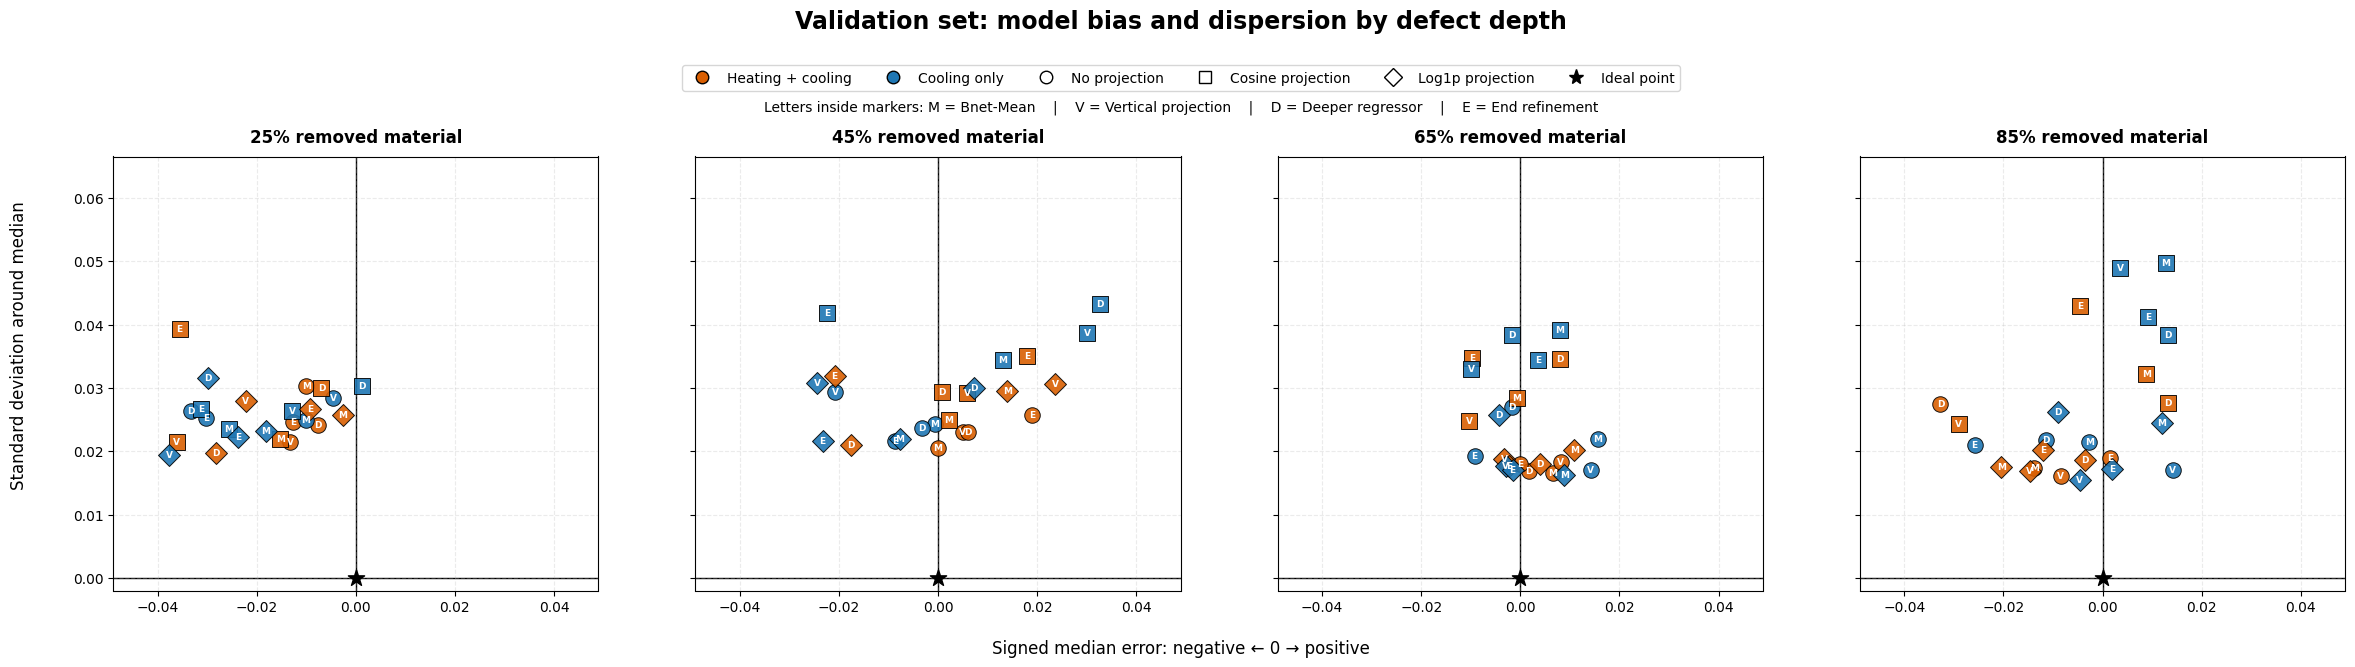

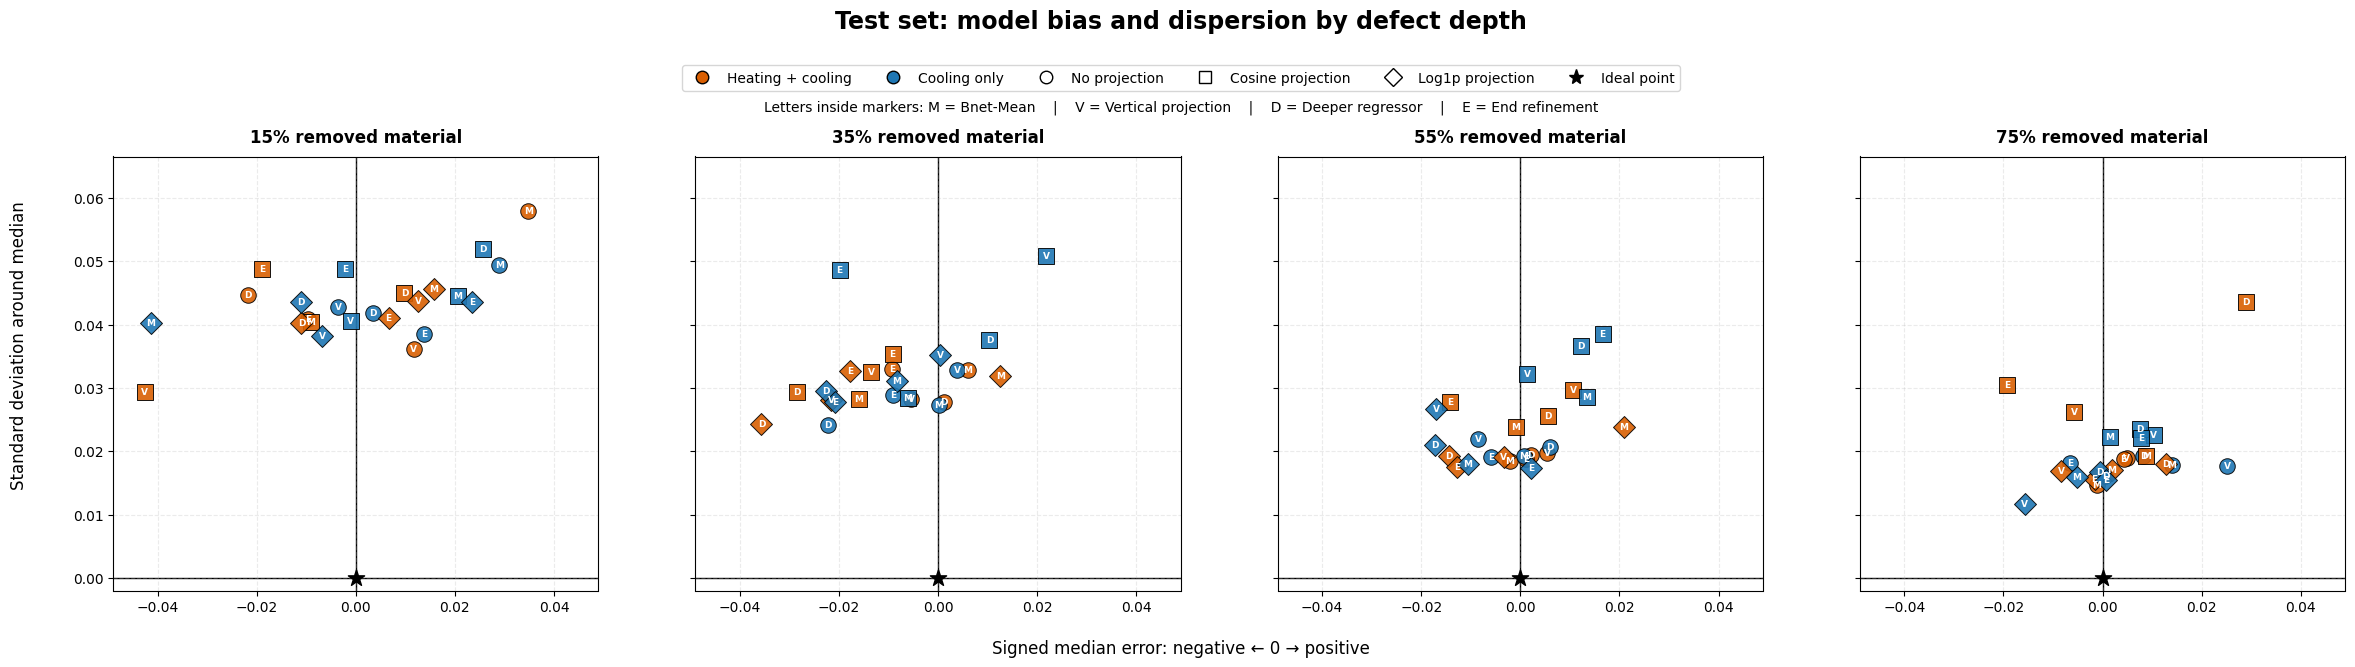

In [34]:
# ============================================================
# 8. CREATE AND SAVE THE TWO FIGURES
# ============================================================

validation_fig = plot_depth_split("Validation")

validation_fig.savefig(
    "validation_bias_dispersion_by_depth.png",
    dpi=300,
    bbox_inches="tight"
)

test_fig = plot_depth_split("Test")

test_fig.savefig(
    "test_bias_dispersion_by_depth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
# ============================================================
# 9. VALIDATION-ONLY DEPTH-STATISTICS RANKING
# ============================================================

validation_specs = [
    spec for spec in depth_specs
    if spec["split"] == "Validation"
]

summary_records = []

for _, model in model_info.iterrows():

    row = int(model["row"])

    signed_values = []
    absolute_signed_values = []
    std_values = []
    origin_distances = []

    depth_distances = {}

    for spec in validation_specs:

        signed_median = pd.to_numeric(
            df.iloc[row][spec["signed_column"]],
            errors="coerce"
        )

        std_median = pd.to_numeric(
            df.iloc[row][spec["std_column"]],
            errors="coerce"
        )

        if pd.isna(signed_median) or pd.isna(std_median):
            continue

        signed_median = float(signed_median)
        std_median = float(std_median)

        distance = np.sqrt(
            signed_median**2 +
            std_median**2
        )

        signed_values.append(signed_median)
        absolute_signed_values.append(abs(signed_median))
        std_values.append(std_median)
        origin_distances.append(distance)

        depth_label = (
            f"Distance at "
            f"{spec['depth'] * 100:.0f}%"
        )

        depth_distances[depth_label] = distance

    full_name = (
        f"{model['training']} | "
        f"{model['projection']} | "
        f"{model['architecture']}"
    )

    summary_records.append({
        "row": row,
        "code": model["code"],
        "Model configuration": full_name,
        "Training": model["training"],
        "Projection": model["projection"],
        "Architecture": model["architecture"],

        # Direction of overall bias; not used for ranking
        "Mean signed median": np.mean(signed_values),

        # Magnitude of bias
        "Mean absolute signed median": np.mean(
            absolute_signed_values
        ),

        # Average dispersion
        "Mean std around median": np.mean(std_values),

        # Primary ranking criterion
        "Mean origin distance": np.mean(origin_distances),

        # Worst validation depth
        "Worst origin distance": np.max(origin_distances),

        **depth_distances
    })

In [36]:
# ============================================================
# 10. SORT AND ASSIGN RANKS
# ============================================================

summary_table = pd.DataFrame(summary_records)

summary_table = summary_table.sort_values(
    by=[
        "Mean origin distance",
        "Worst origin distance"
    ],
    ascending=True
).reset_index(drop=True)

# Overall rank
summary_table.insert(
    0,
    "Overall rank",
    np.arange(1, len(summary_table) + 1)
)

# Rank separately within H+C and cooling-only groups
summary_table["Training-group rank"] = (
    summary_table
    .groupby("Training", sort=False)
    .cumcount()
    + 1
)

# Identify the two previous IoU candidates
iou_candidates = {
    2: "H+C IoU candidate",
    26: "Cooling IoU candidate"
}

summary_table["IoU candidate"] = (
    summary_table["row"]
    .map(iou_candidates)
    .fillna("")
)

In [37]:
display_columns = [
    "Overall rank",
    "Training-group rank",
    "IoU candidate",
    "code",
    "Model configuration",
    "Mean signed median",
    "Mean absolute signed median",
    "Mean std around median",
    "Mean origin distance",
    "Worst origin distance",
    "Distance at 25%",
    "Distance at 45%",
    "Distance at 65%",
    "Distance at 85%"
]

print("Validation ranking based on depth statistics:\n")

display(
    summary_table[display_columns]
    .round(5)
    .style
    .background_gradient(
        subset=[
            "Mean origin distance",
            "Worst origin distance"
        ],
        cmap="RdYlGn_r"
    )
)

Validation ranking based on depth statistics:



,Overall rank,Training-group rank,IoU candidate,code,Model configuration,Mean signed median,Mean absolute signed median,Mean std around median,Mean origin distance,Worst origin distance,Distance at 25%,Distance at 45%,Distance at 65%,Distance at 85%
0,1,1,H+C IoU candidate,HC-NP-V,H+C | No projection | Bnet-Vertical projection,-0.002140,0.008680,0.019740,0.021750,0.025160,0.025160,0.023640,0.020070,0.018140
1,2,2,,HC-NP-M,H+C | No projection | Bnet-Mean,-0.004340,0.007590,0.021210,0.023120,0.031990,0.031990,0.020460,0.017840,0.022200
2,3,3,,HC-NP-E,H+C | No projection | Bnet-End refinement,0.001940,0.008310,0.021820,0.024160,0.032020,0.027700,0.032020,0.017990,0.018930
3,4,1,Cooling IoU candidate,C-L1-M,Cooling only | Log1p projection | Bnet-Mean,-0.001250,0.011660,0.021460,0.024610,0.029460,0.029460,0.023220,0.018520,0.027240
4,5,2,,C-L1-E,Cooling only | Log1p projection | Bnet-End refinement,-0.011650,0.012620,0.019550,0.024690,0.032520,0.032520,0.031750,0.017170,0.017320
5,6,4,,HC-L1-D,H+C | Log1p projection | Bnet-Deeper regressor,-0.011400,0.013370,0.019350,0.024840,0.034520,0.034520,0.027380,0.018460,0.019000
6,7,3,,C-NP-M,Cooling only | No projection | Bnet-Mean,0.000550,0.007300,0.023150,0.024950,0.026940,0.026930,0.024270,0.026940,0.021660
7,8,5,,HC-L1-E,H+C | Log1p projection | Bnet-End refinement,-0.011080,0.011080,0.024080,0.026880,0.038070,0.028180,0.038070,0.017850,0.023450
8,9,6,,HC-L1-M,H+C | Log1p projection | Bnet-Mean,0.000460,0.011980,0.023240,0.027090,0.032610,0.025950,0.032610,0.022890,0.026900
9,10,7,,HC-NP-D,H+C | No projection | Bnet-Deeper regressor,-0.008130,0.012040,0.022910,0.027230,0.042740,0.025300,0.023870,0.017010,0.042740


In [38]:
overall_winner = summary_table.iloc[0]

print("Overall validation winner from depth statistics:")
print(overall_winner["Model configuration"])
print(
    "Mean distance from origin:",
    round(overall_winner["Mean origin distance"], 5)
)

print(
    "\nIs it one of the previous IoU candidates?",
    int(overall_winner["row"]) in [2, 26]
)

Overall validation winner from depth statistics:
H+C | No projection | Bnet-Vertical projection
Mean distance from origin: 0.02175

Is it one of the previous IoU candidates? True


In [47]:
# ============================================================
# 2. MODEL ORDER: H+C DIRECTLY FOLLOWED BY COOLING ONLY
# ============================================================

architectures = [
    ("M", "Bnet-Mean"),
    ("V", "Bnet-Vertical projection"),
    ("D", "Bnet-Deeper regressor"),
    ("E", "Bnet-End refinement")
]

projection_blocks = [
    {
        "code": "NP",
        "name": "No projection",
        "hc_start": 1,
        "c_start": 6
    },
    {
        "code": "COS",
        "name": "Cosine projection",
        "hc_start": 11,
        "c_start": 16
    },
    {
        "code": "L1",
        "name": "Log1p projection",
        "hc_start": 21,
        "c_start": 26
    }
]

paired_records = []

for block in projection_blocks:

    for offset, (architecture_code, architecture_name) in enumerate(
        architectures
    ):
        # Heating + cooling version
        paired_records.append({
            "row": block["hc_start"] + offset,
            "code": (
                f"HC-{block['code']}-{architecture_code}"
            ),
            "training": "H+C",
            "projection": block["name"],
            "projection_code": block["code"],
            "architecture": architecture_name,
            "architecture_code": architecture_code,
            "plot_label": (
                f"{block['code']} | "
                f"{architecture_code} | H+C"
            )
        })

        # Cooling-only version
        paired_records.append({
            "row": block["c_start"] + offset,
            "code": (
                f"C-{block['code']}-{architecture_code}"
            ),
            "training": "Cooling only",
            "projection": block["name"],
            "projection_code": block["code"],
            "architecture": architecture_name,
            "architecture_code": architecture_code,
            "plot_label": (
                f"{block['code']} | "
                f"{architecture_code} | C"
            )
        })

paired_model_info = pd.DataFrame(paired_records)

print(
    paired_model_info[
        [
            "code",
            "row",
            "training",
            "projection",
            "architecture"
        ]
    ].to_string(index=False)
)

    code  row     training        projection             architecture
 HC-NP-M    1          H+C     No projection                Bnet-Mean
  C-NP-M    6 Cooling only     No projection                Bnet-Mean
 HC-NP-V    2          H+C     No projection Bnet-Vertical projection
  C-NP-V    7 Cooling only     No projection Bnet-Vertical projection
 HC-NP-D    3          H+C     No projection    Bnet-Deeper regressor
  C-NP-D    8 Cooling only     No projection    Bnet-Deeper regressor
 HC-NP-E    4          H+C     No projection      Bnet-End refinement
  C-NP-E    9 Cooling only     No projection      Bnet-End refinement
HC-COS-M   11          H+C Cosine projection                Bnet-Mean
 C-COS-M   16 Cooling only Cosine projection                Bnet-Mean
HC-COS-V   12          H+C Cosine projection Bnet-Vertical projection
 C-COS-V   17 Cooling only Cosine projection Bnet-Vertical projection
HC-COS-D   13          H+C Cosine projection    Bnet-Deeper regressor
 C-COS-D   18 Coolin

In [46]:
# ============================================================
# BAR-PLOT PREPARATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# paired_model_info must already exist from the previous code.
# It is ordered as:
# H+C Mean, C Mean, H+C Vertical, C Vertical, etc.

hc_models = paired_model_info.iloc[0::2].reset_index(drop=True)
c_models = paired_model_info.iloc[1::2].reset_index(drop=True)

# Twelve paired configurations
configuration_labels = [
    f"{projection}\n{architecture}"
    for projection, architecture in zip(
        hc_models["projection_code"],
        hc_models["architecture_code"]
    )
]

x = np.arange(len(configuration_labels))

hc_color = "#d95f02"
c_color = "#1f77b4"

In [48]:
# ============================================================
# FUNCTION TO EXTRACT METRIC VALUES
# ============================================================

def extract_metric_values(
    models,
    metric_column,
    suffix
):
    column = (
        metric_column
        if suffix == ""
        else f"{metric_column}{suffix}"
    )

    values = []

    for _, model in models.iterrows():

        value = pd.to_numeric(
            df.iloc[int(model["row"])][column],
            errors="coerce"
        )

        values.append(value)

    return np.asarray(values, dtype=float)

In [49]:
# ============================================================
# FUNCTION TO CREATE ONE COMPLETE METRIC FIGURE
# ============================================================

def plot_global_metric_bars(
    metric_name,
    metric_column
):
    # Top row: validation
    # Bottom row: test
    all_depths = [
        ("Validation", "25%", ""),
        ("Validation", "45%", ".1"),
        ("Validation", "65%", ".2"),
        ("Validation", "85%", ".3"),

        ("Test", "15%", ".4"),
        ("Test", "35%", ".5"),
        ("Test", "55%", ".6"),
        ("Test", "75%", ".7")
    ]

    # Calculate one common y limit for all eight panels
    all_metric_values = []

    for _, _, suffix in all_depths:

        all_metric_values.extend(
            extract_metric_values(
                hc_models,
                metric_column,
                suffix
            )
        )

        all_metric_values.extend(
            extract_metric_values(
                c_models,
                metric_column,
                suffix
            )
        )

    y_max = np.nanmax(all_metric_values) * 1.12

    fig, axes = plt.subplots(
        2, 4,
        figsize=(24, 12),
        sharey=True
    )

    bar_width = 0.36

    for panel_index, (
        split,
        depth_label,
        suffix
    ) in enumerate(all_depths):

        row = 0 if split == "Validation" else 1
        column = panel_index % 4

        ax = axes[row, column]

        hc_values = extract_metric_values(
            hc_models,
            metric_column,
            suffix
        )

        c_values = extract_metric_values(
            c_models,
            metric_column,
            suffix
        )

        # H+C bar
        ax.bar(
            x - bar_width / 2,
            hc_values,
            width=bar_width,
            color=hc_color,
            edgecolor="black",
            linewidth=0.7,
            label="Heating + cooling"
        )

        # Cooling-only bar
        ax.bar(
            x + bar_width / 2,
            c_values,
            width=bar_width,
            color=c_color,
            edgecolor="black",
            linewidth=0.7,
            label="Cooling only"
        )

        ax.set_title(
            f"{split} — {depth_label} removed material",
            fontsize=12,
            fontweight="bold"
        )

        ax.set_xticks(x)
        ax.set_xticklabels(
            configuration_labels,
            rotation=55,
            ha="right",
            fontsize=8
        )

        ax.set_ylim(0, y_max)

        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.3
        )

        ax.set_axisbelow(True)

        # Separate projection groups:
        # NP models 0–3, COS models 4–7, L1 models 8–11
        ax.axvline(
            3.5,
            color="grey",
            linestyle=":",
            linewidth=1.2
        )

        ax.axvline(
            7.5,
            color="grey",
            linestyle=":",
            linewidth=1.2
        )

        if column == 0:
            ax.set_ylabel(
                f"Global {metric_name} [mm]",
                fontsize=11
            )

    fig.suptitle(
        f"Whole-scene {metric_name}: "
        "H+C versus cooling-only configurations",
        fontsize=17,
        fontweight="bold",
        y=0.985
    )

    # One common legend
    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        bbox_to_anchor=(0.5, 0.945),
        frameon=True
    )

    # Configuration-code explanation
    fig.text(
        0.5,
        0.905,
        "NP = no projection   |   "
        "COS = cosine projection   |   "
        "L1 = log1p projection   |   "
        "M = Mean   |   "
        "V = Vertical projection   |   "
        "D = Deeper regressor   |   "
        "E = End refinement",
        ha="center",
        fontsize=10
    )

    fig.subplots_adjust(
        left=0.06,
        right=0.985,
        bottom=0.10,
        top=0.85,
        hspace=0.42,
        wspace=0.12
    )

    return fig

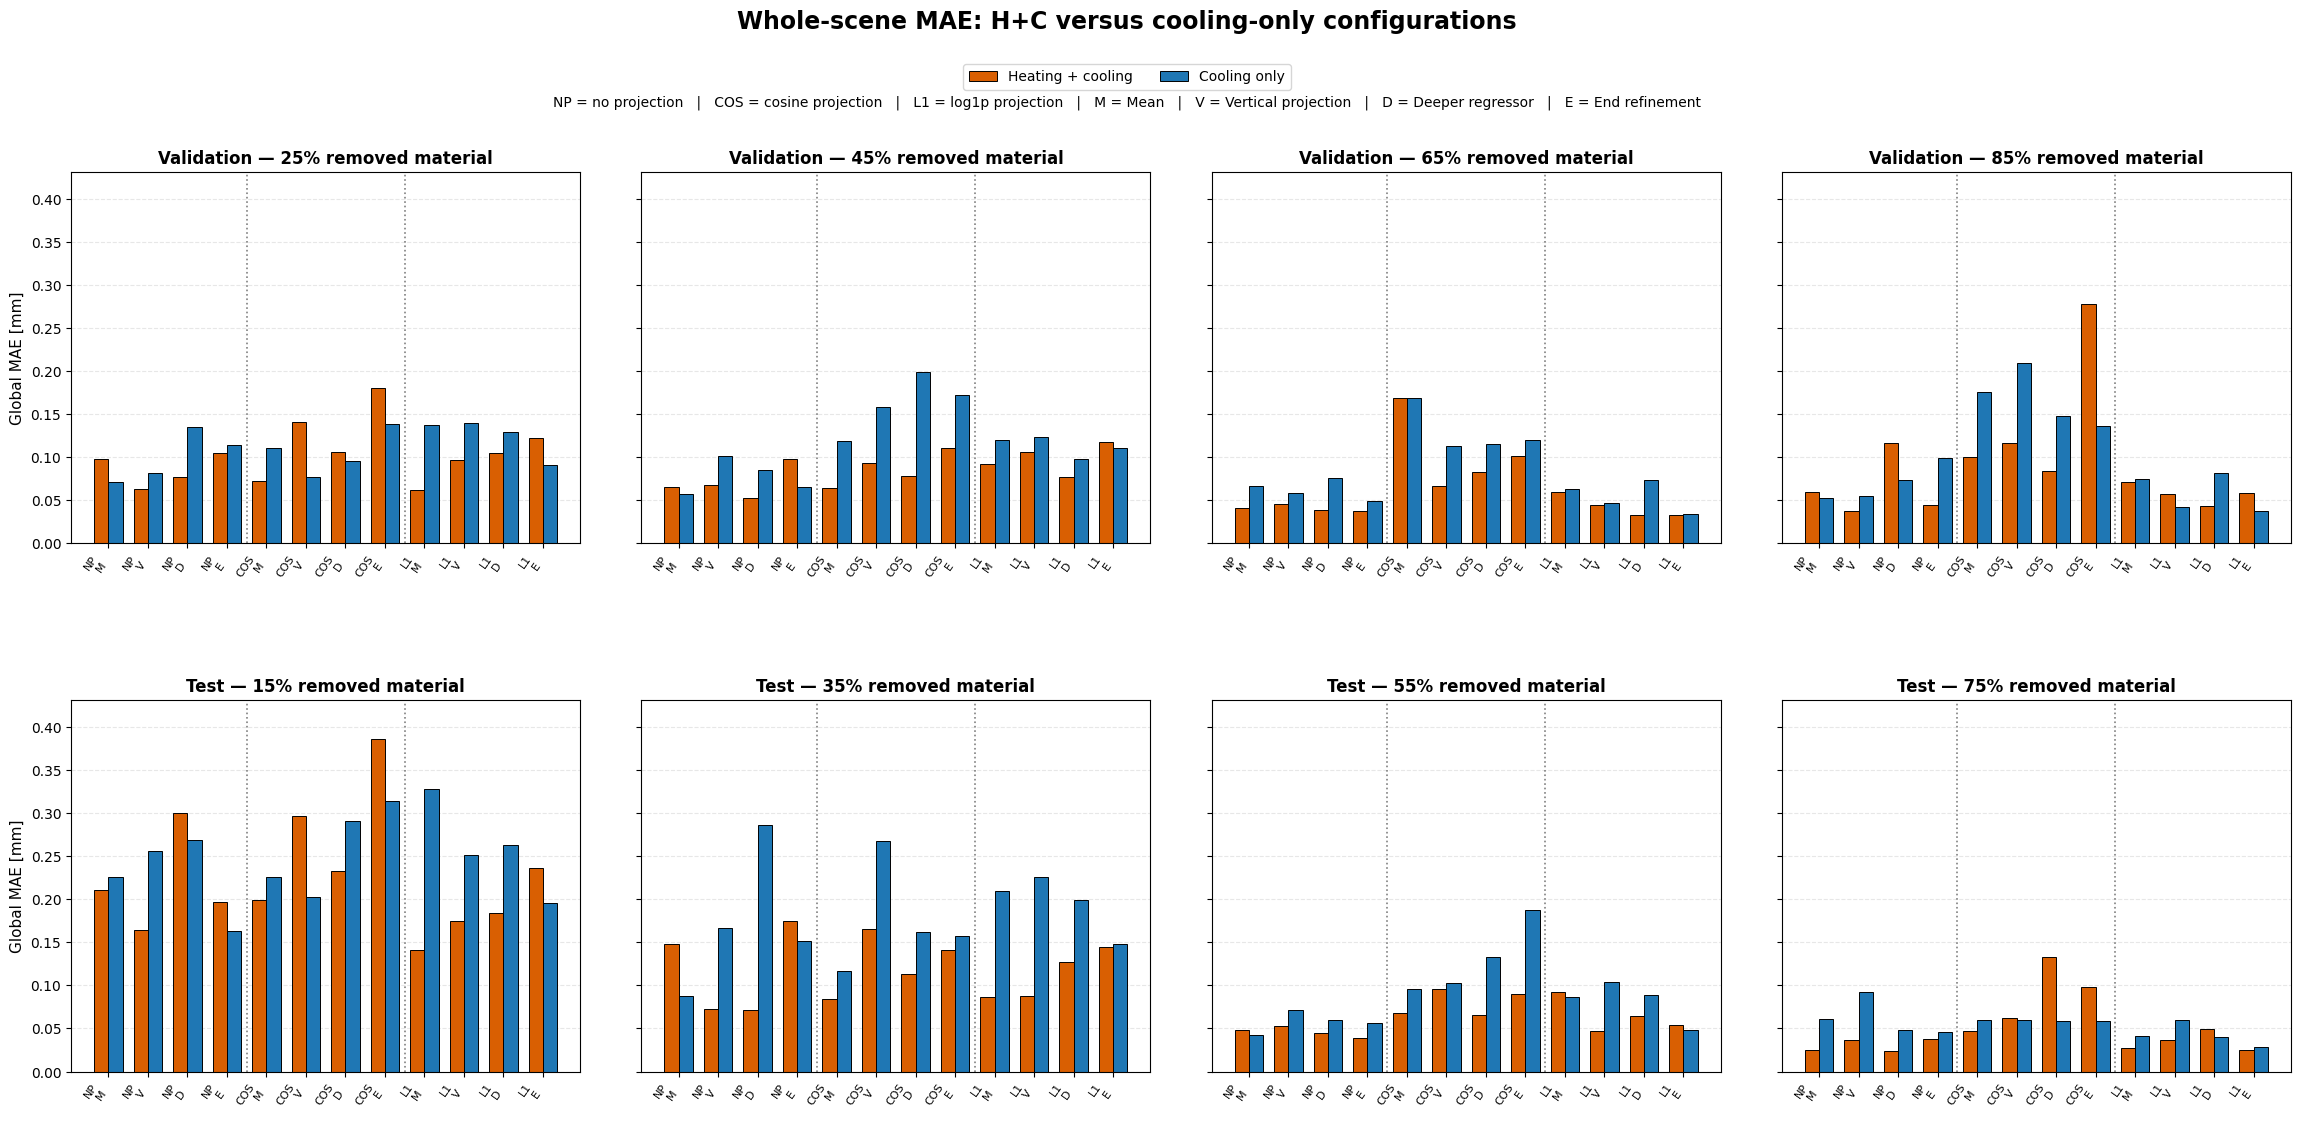

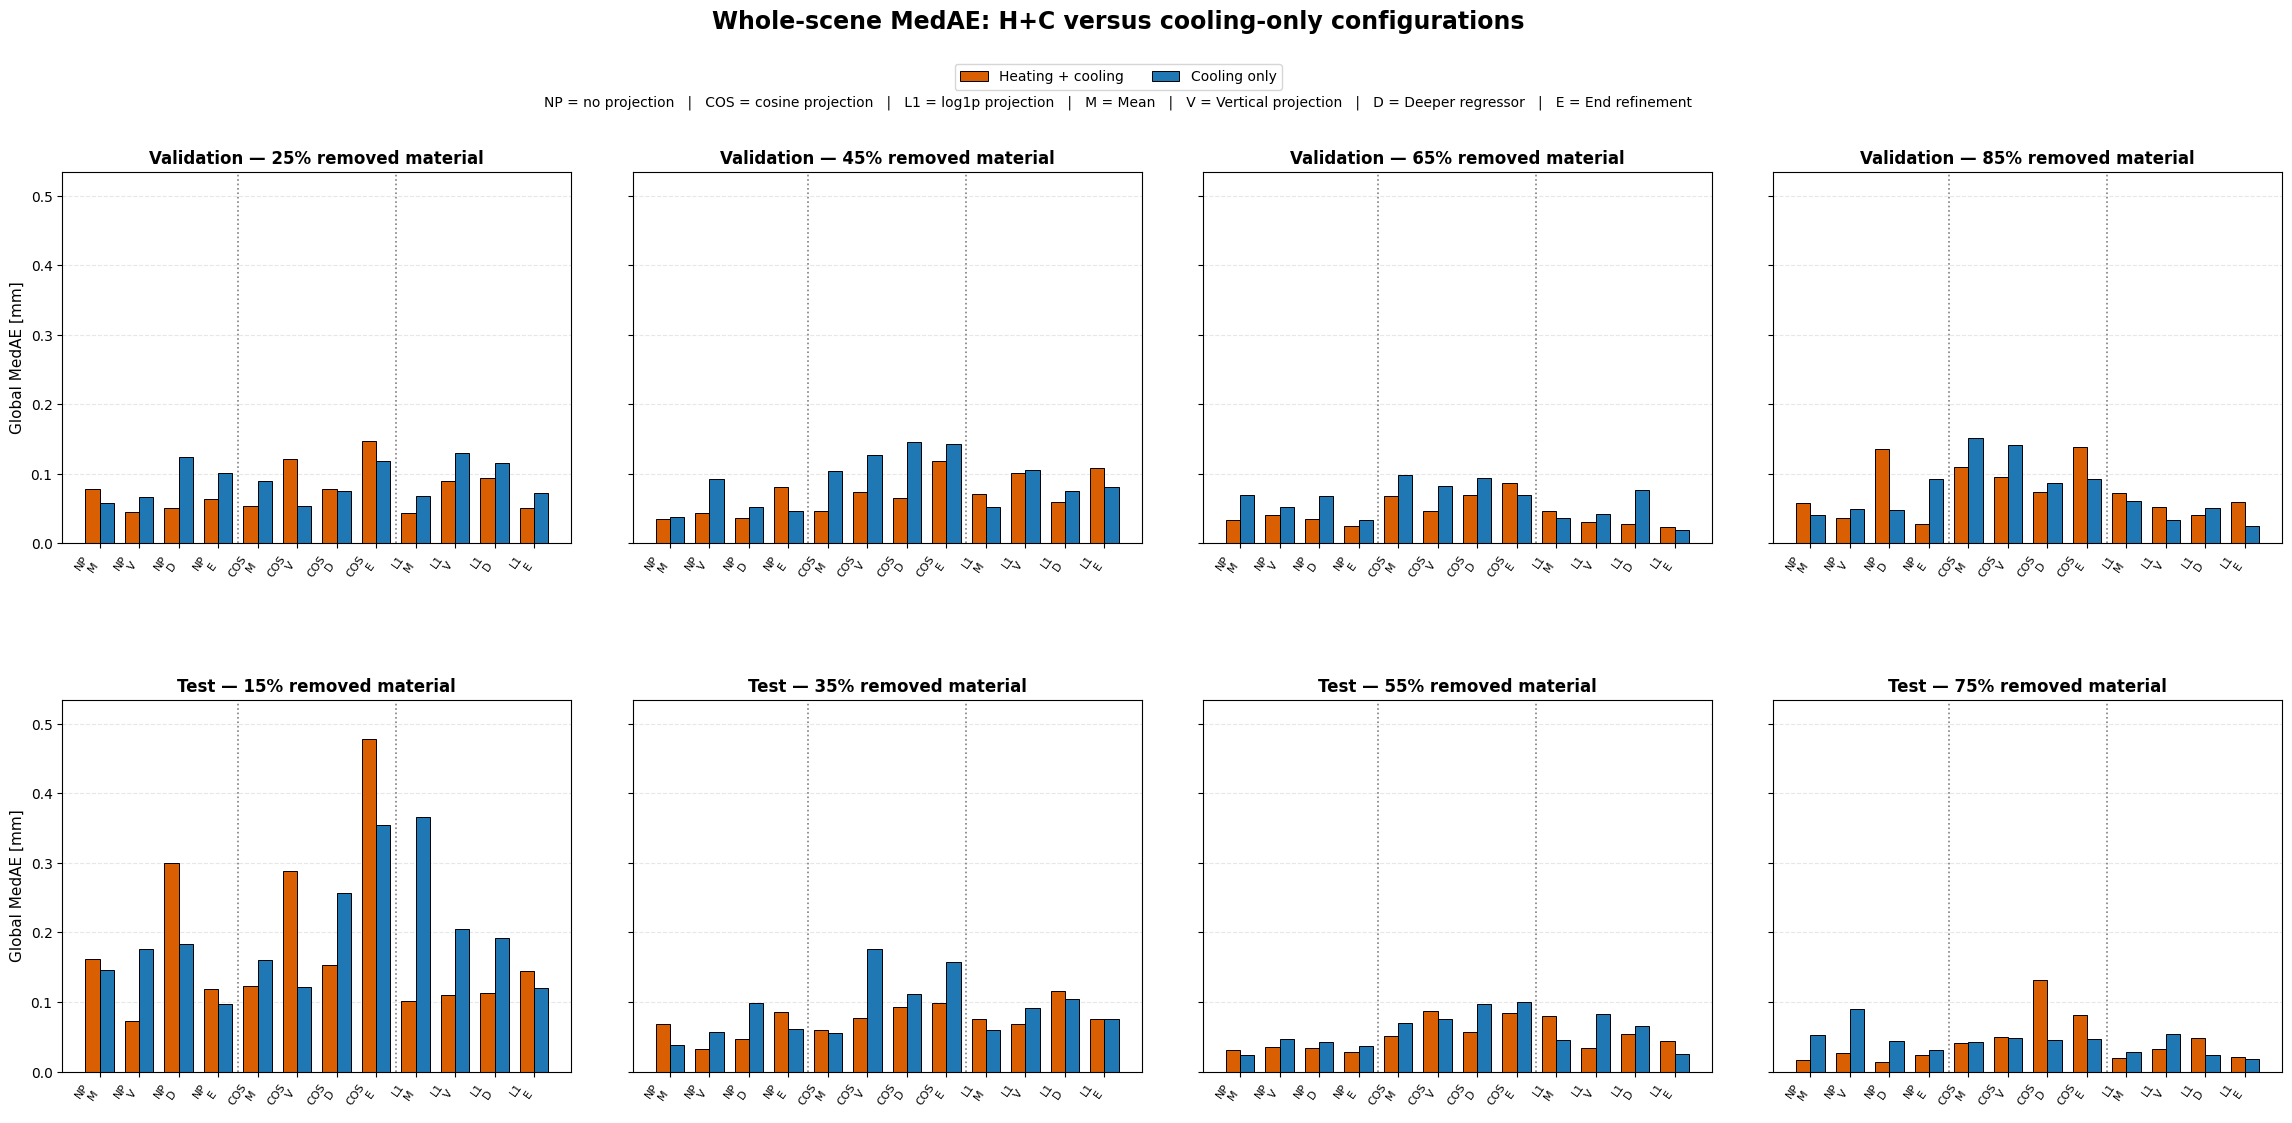

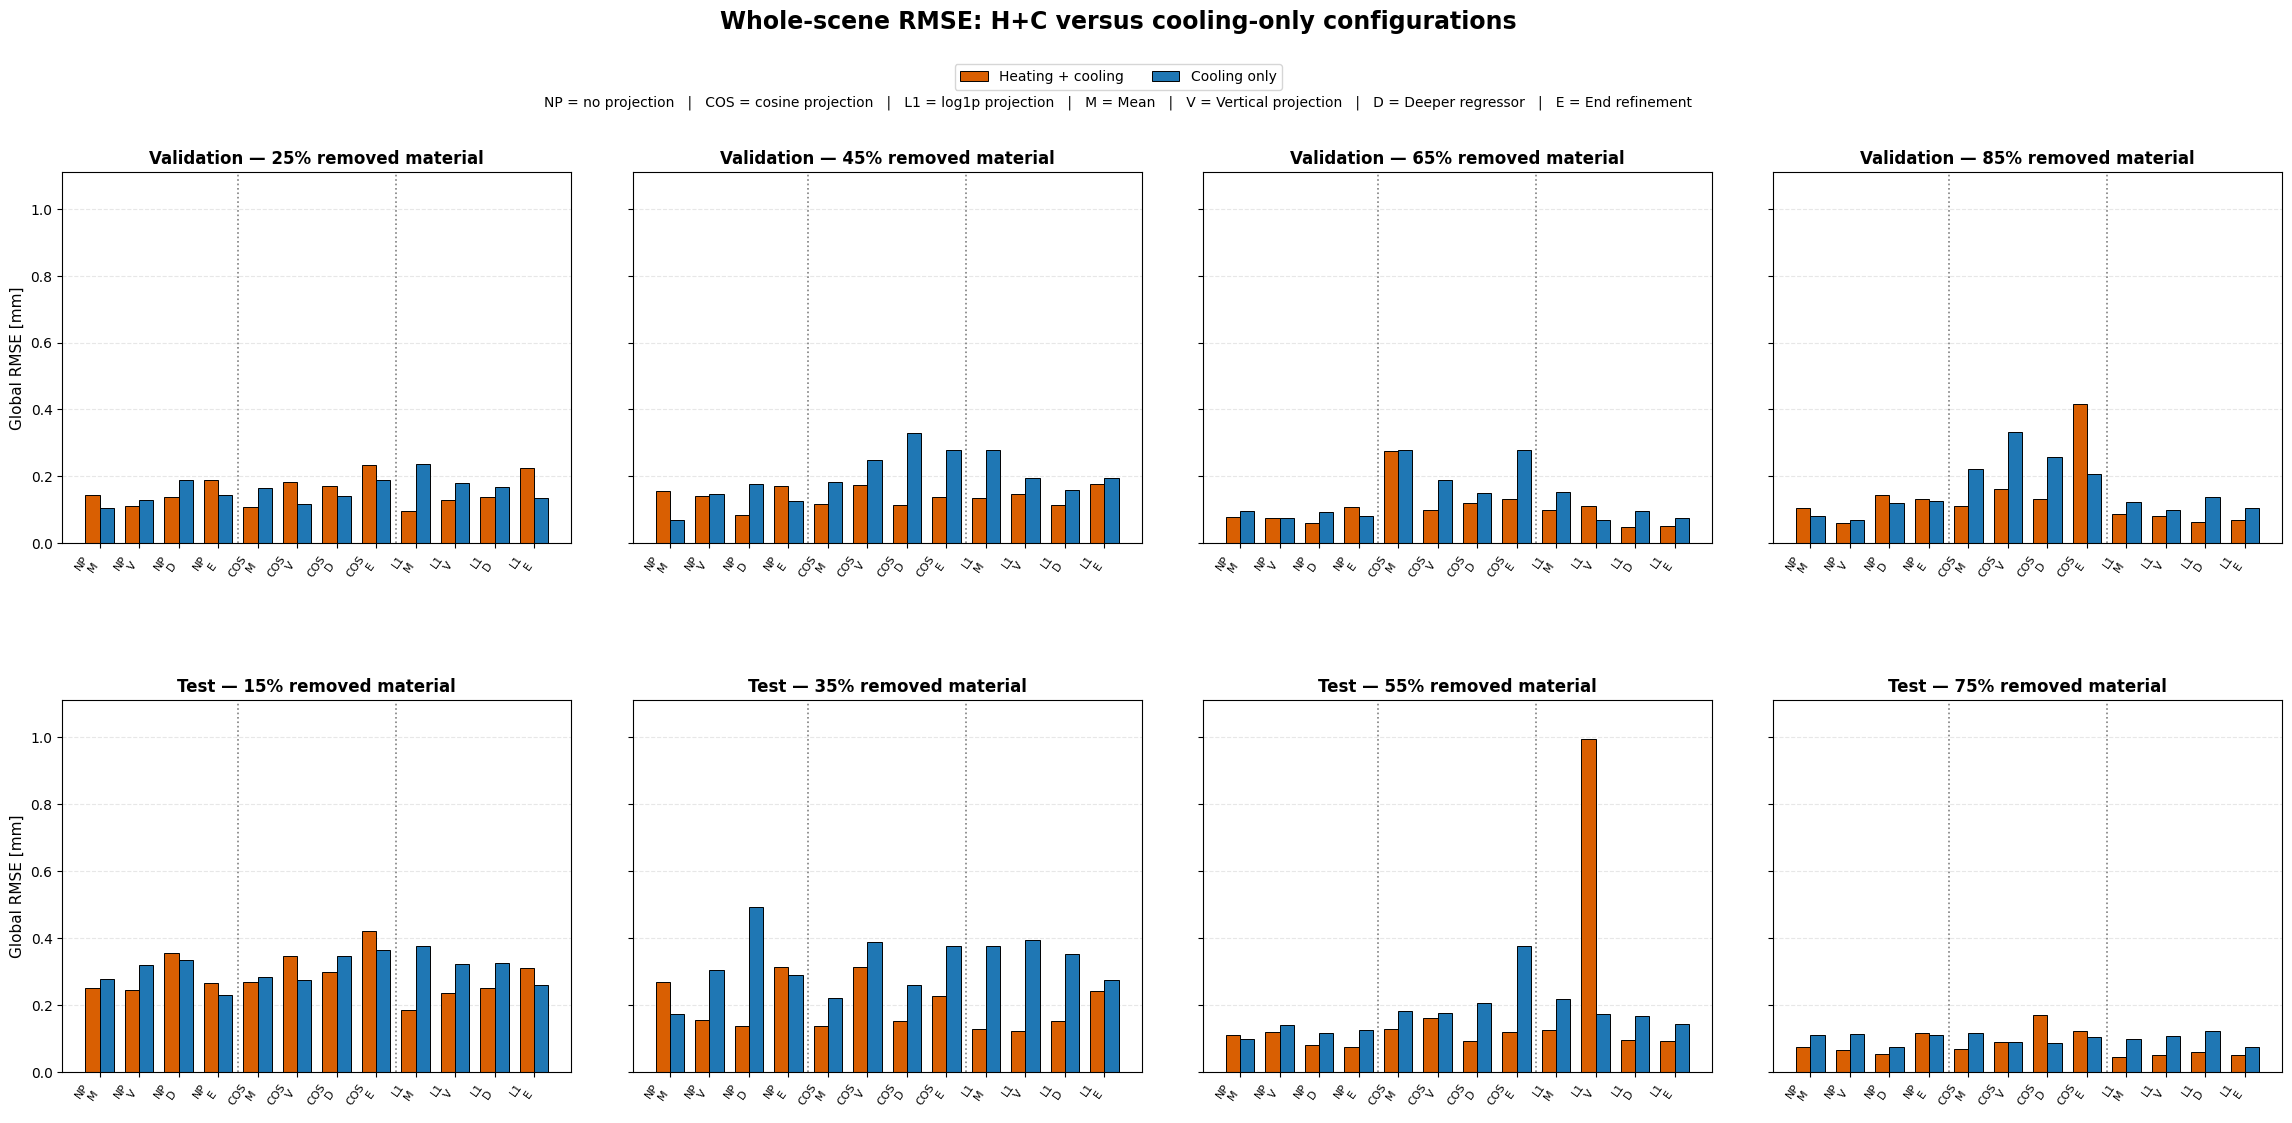

In [50]:
# ============================================================
# GENERATE MAE, MedAE AND RMSE FIGURES
# ============================================================

mae_figure = plot_global_metric_bars(
    metric_name="MAE",
    metric_column="MAE [mm]"
)

medae_figure = plot_global_metric_bars(
    metric_name="MedAE",
    metric_column="MedAE [mm]"
)

rmse_figure = plot_global_metric_bars(
    metric_name="RMSE",
    metric_column="RMSE [mm]"
)

plt.show()

In [51]:
# ============================================================
# CREATE global_summary FROM THE ORIGINAL df
# ============================================================

import numpy as np
import pandas as pd

validation_depths = [
    ("25%", ""),
    ("45%", ".1"),
    ("65%", ".2"),
    ("85%", ".3")
]

test_depths = [
    ("15%", ".4"),
    ("35%", ".5"),
    ("55%", ".6"),
    ("75%", ".7")
]

metrics = {
    "MAE": "MAE [mm]",
    "MedAE": "MedAE [mm]",
    "RMSE": "RMSE [mm]"
}


def get_column_name(base_name, suffix):
    if suffix == "":
        return base_name

    return f"{base_name}{suffix}"


global_summary_records = []

for _, model in paired_model_info.iterrows():

    row = int(model["row"])

    record = {
        "row": row,
        "code": model["code"],
        "Training": model["training"],
        "Projection": model["projection"],
        "Architecture": model["architecture"],
        "Model configuration": (
            f"{model['training']} | "
            f"{model['projection']} | "
            f"{model['architecture']}"
        )
    }

    for metric_name, metric_column in metrics.items():

        validation_values = []
        test_values = []

        # Validation depths
        for _, suffix in validation_depths:

            column = get_column_name(
                metric_column,
                suffix
            )

            value = pd.to_numeric(
                df.iloc[row][column],
                errors="coerce"
            )

            validation_values.append(value)

        # Test depths
        for _, suffix in test_depths:

            column = get_column_name(
                metric_column,
                suffix
            )

            value = pd.to_numeric(
                df.iloc[row][column],
                errors="coerce"
            )

            test_values.append(value)

        record[f"Validation mean {metric_name}"] = (
            np.nanmean(validation_values)
        )

        record[f"Test mean {metric_name}"] = (
            np.nanmean(test_values)
        )

    global_summary_records.append(record)

# This is where global_summary is created
global_summary = pd.DataFrame(global_summary_records)

print("global_summary created successfully:")
print(global_summary.head())

global_summary created successfully:
   row     code      Training     Projection              Architecture  \
0    1  HC-NP-M           H+C  No projection                 Bnet-Mean   
1    6   C-NP-M  Cooling only  No projection                 Bnet-Mean   
2    2  HC-NP-V           H+C  No projection  Bnet-Vertical projection   
3    7   C-NP-V  Cooling only  No projection  Bnet-Vertical projection   
4    3  HC-NP-D           H+C  No projection     Bnet-Deeper regressor   

                                 Model configuration  Validation mean MAE  \
0                    H+C | No projection | Bnet-Mean             0.066006   
1           Cooling only | No projection | Bnet-Mean             0.062128   
2     H+C | No projection | Bnet-Vertical projection             0.053772   
3  Cooling only | No projection | Bnet-Vertical p...             0.074258   
4        H+C | No projection | Bnet-Deeper regressor             0.071398   

   Test mean MAE  Validation mean MedAE  Test mean MedA

In [52]:
# ============================================================
# CREATE GLOBAL METRIC RANKS
# ============================================================

for metric_name in ["MAE", "MedAE", "RMSE"]:

    global_summary[f"Validation {metric_name} rank"] = (
        global_summary[f"Validation mean {metric_name}"]
        .rank(
            method="min",
            ascending=True
        )
        .astype(int)
    )

    global_summary[f"Test {metric_name} rank"] = (
        global_summary[f"Test mean {metric_name}"]
        .rank(
            method="min",
            ascending=True
        )
        .astype(int)
    )

# All three metrics
global_summary["Validation three-metric rank score"] = (
    global_summary[
        [
            "Validation MAE rank",
            "Validation MedAE rank",
            "Validation RMSE rank"
        ]
    ].mean(axis=1)
)

global_summary["Test three-metric rank score"] = (
    global_summary[
        [
            "Test MAE rank",
            "Test MedAE rank",
            "Test RMSE rank"
        ]
    ].mean(axis=1)
)

# Recommended score based on MAE and RMSE
global_summary["Validation recommended rank score"] = (
    global_summary[
        [
            "Validation MAE rank",
            "Validation RMSE rank"
        ]
    ].mean(axis=1)
)

global_summary["Test recommended rank score"] = (
    global_summary[
        [
            "Test MAE rank",
            "Test RMSE rank"
        ]
    ].mean(axis=1)
)

In [53]:
# ============================================================
# SORT BY VALIDATION PERFORMANCE
# ============================================================

global_summary = global_summary.sort_values(
    by=[
        "Validation recommended rank score",
        "Validation mean MAE",
        "Validation mean RMSE"
    ],
    ascending=True
).reset_index(drop=True)

global_summary.insert(
    0,
    "Global validation rank",
    np.arange(1, len(global_summary) + 1)
)

global_summary["Training-group rank"] = (
    global_summary
    .groupby("Training", sort=False)
    .cumcount()
    + 1
)

global_summary["Test rank"] = (
    global_summary["Test recommended rank score"]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)

# Mark previous IoU candidates
iou_candidates = {
    2: "H+C IoU candidate",
    26: "Cooling IoU candidate"
}

global_summary["IoU candidate"] = (
    global_summary["row"]
    .map(iou_candidates)
    .fillna("")
)

print("global_summary ranked successfully.")

global_summary ranked successfully.


In [54]:
global_display_columns = [
    "Global validation rank",
    "Training-group rank",
    "Test rank",
    "IoU candidate",
    "code",
    "Model configuration",

    "Validation mean MAE",
    "Validation mean MedAE",
    "Validation mean RMSE",

    "Validation MAE rank",
    "Validation MedAE rank",
    "Validation RMSE rank",

    "Validation recommended rank score",
    "Validation three-metric rank score",

    "Test mean MAE",
    "Test mean MedAE",
    "Test mean RMSE"
]

display(
    global_summary[global_display_columns]
    .round(4)
    .style
    .background_gradient(
        subset=[
            "Validation mean MAE",
            "Validation mean RMSE",
            "Validation recommended rank score"
        ],
        cmap="RdYlGn_r"
    )
)

,Global validation rank,Training-group rank,Test rank,IoU candidate,code,Model configuration,Validation mean MAE,Validation mean MedAE,Validation mean RMSE,Validation MAE rank,Validation MedAE rank,Validation RMSE rank,Validation recommended rank score,Validation three-metric rank score,Test mean MAE,Test mean MedAE,Test mean RMSE
0,1,1,5,,C-NP-M,Cooling only | No projection | Bnet-Mean,0.062100,0.051700,0.088400,2,5,1,1.500000,2.666700,0.104300,0.065000,0.162900
1,2,1,1,H+C IoU candidate,HC-NP-V,H+C | No projection | Bnet-Vertical projection,0.053800,0.041500,0.097300,1,1,3,2.000000,1.666700,0.081600,0.041800,0.143900
2,3,2,4,,HC-L1-D,H+C | Log1p projection | Bnet-Deeper regressor,0.064500,0.055500,0.090900,3,7,2,2.500000,4.000000,0.106500,0.082800,0.138700
3,4,3,1,,HC-L1-M,H+C | Log1p projection | Bnet-Mean,0.071200,0.058700,0.104900,6,8,4,5.000000,6.000000,0.086700,0.069400,0.119200
4,5,4,8,,HC-NP-M,H+C | No projection | Bnet-Mean,0.066000,0.051400,0.121600,4,4,9,6.500000,5.666700,0.107900,0.069600,0.175000
5,6,5,6,,HC-NP-D,H+C | No projection | Bnet-Deeper regressor,0.071400,0.064700,0.107400,7,10,6,6.500000,7.666700,0.109900,0.098800,0.156000
6,7,2,15,,C-NP-V,Cooling only | No projection | Bnet-Vertical projection,0.074300,0.065500,0.105700,9,11,5,7.000000,8.333300,0.146700,0.092500,0.217700
7,8,3,9,,C-L1-E,Cooling only | Log1p projection | Bnet-End refinement,0.068700,0.049800,0.128000,5,3,10,7.500000,6.000000,0.105200,0.059600,0.186800
8,9,6,13,,HC-L1-V,H+C | Log1p projection | Bnet-Vertical projection,0.076400,0.068300,0.117200,10,12,7,8.500000,9.666700,0.086600,0.061600,0.349600
9,10,4,7,,C-NP-E,Cooling only | No projection | Bnet-End refinement,0.081900,0.068500,0.120300,11,13,8,9.500000,10.666700,0.104400,0.056500,0.186600


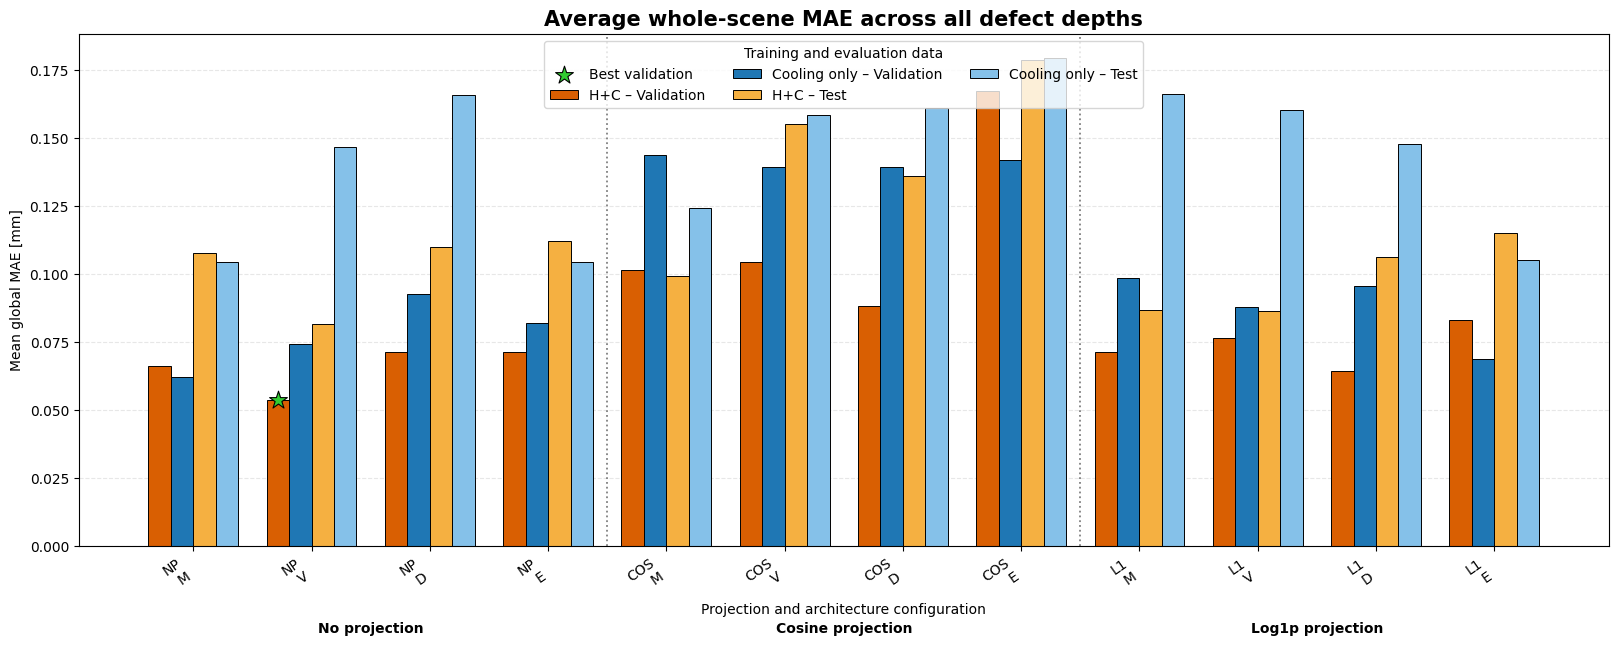

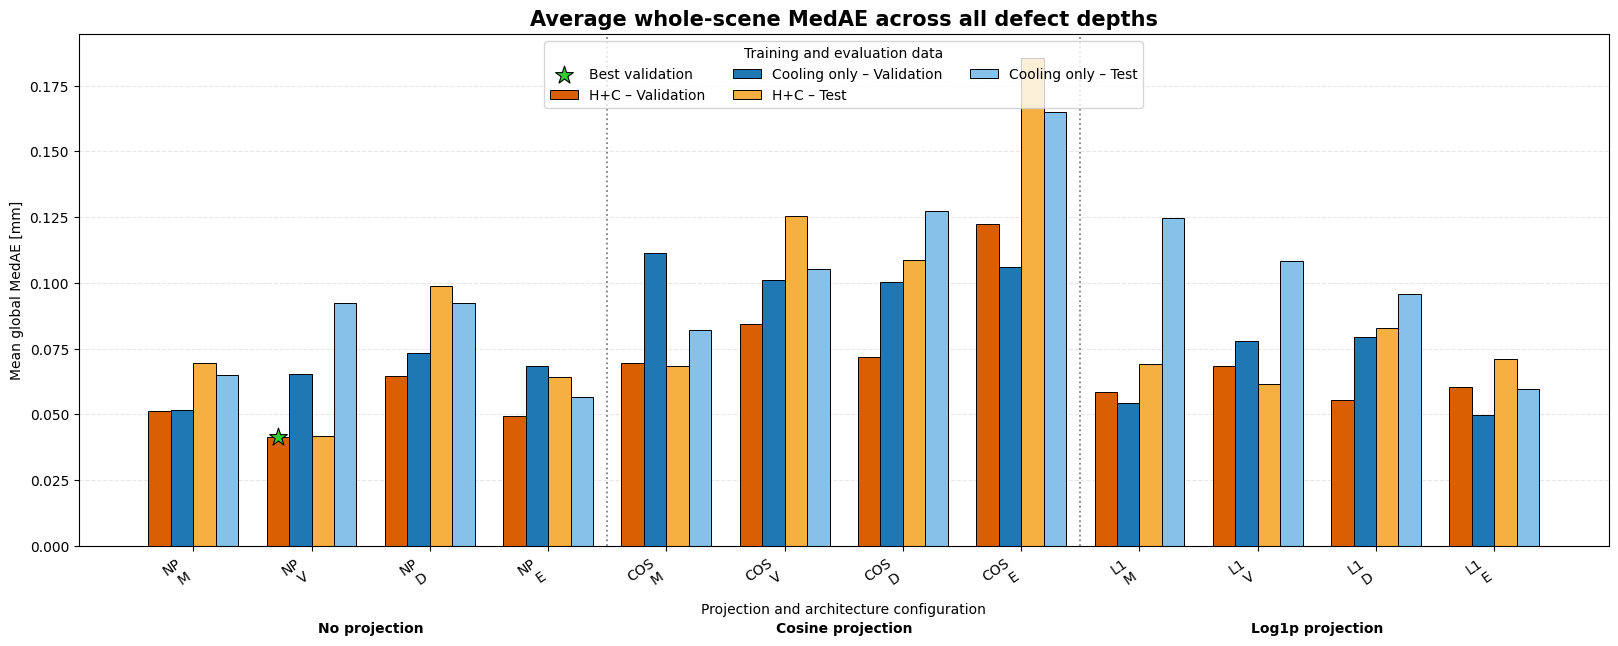

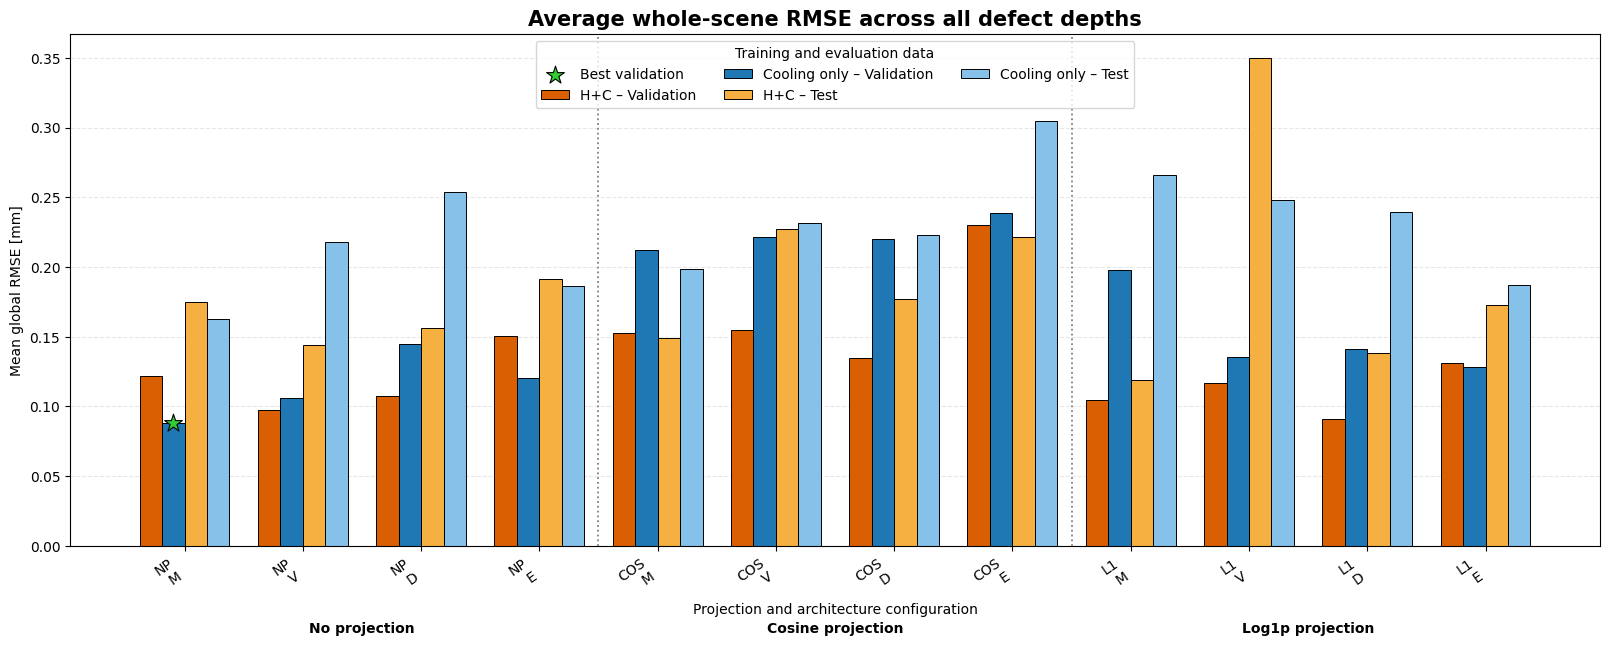

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PREPARE PAIRED MODEL CONFIGURATIONS
# ============================================================

# paired_model_info is ordered:
# H+C Mean, C Mean, H+C Vertical, C Vertical, etc.
hc_models = paired_model_info.iloc[0::2].reset_index(drop=True)
c_models = paired_model_info.iloc[1::2].reset_index(drop=True)

configuration_labels = [
    f"{projection}\n{architecture}"
    for projection, architecture in zip(
        hc_models["projection_code"],
        hc_models["architecture_code"]
    )
]

x = np.arange(len(configuration_labels))

# Use row number to access the already averaged values
summary_lookup = global_summary.set_index("row")

# ============================================================
# COLOURS
# ============================================================

hc_validation_color = "#d95f02"   # Dark orange
hc_test_color = "#f5b041"         # Light orange

c_validation_color = "#1f77b4"    # Dark blue
c_test_color = "#85c1e9"          # Light blue

# ============================================================
# EXTRACT AVERAGED METRIC VALUES
# ============================================================

def extract_average_values(
    models,
    split,
    metric_name
):
    column = f"{split} mean {metric_name}"

    return np.asarray(
        [
            summary_lookup.loc[
                int(model["row"]),
                column
            ]
            for _, model in models.iterrows()
        ],
        dtype=float
    )

# ============================================================
# CREATE ONE AVERAGED BAR PLOT
# ============================================================

def plot_averaged_metric(metric_name):

    hc_validation = extract_average_values(
        hc_models,
        "Validation",
        metric_name
    )

    c_validation = extract_average_values(
        c_models,
        "Validation",
        metric_name
    )

    hc_test = extract_average_values(
        hc_models,
        "Test",
        metric_name
    )

    c_test = extract_average_values(
        c_models,
        "Test",
        metric_name
    )

    fig, ax = plt.subplots(
        figsize=(17, 8)
    )

    bar_width = 0.19

    # Validation bars are on the left side
    hc_validation_bars = ax.bar(
        x - 1.5 * bar_width,
        hc_validation,
        width=bar_width,
        color=hc_validation_color,
        edgecolor="black",
        linewidth=0.7,
        label="H+C – Validation"
    )

    c_validation_bars = ax.bar(
        x - 0.5 * bar_width,
        c_validation,
        width=bar_width,
        color=c_validation_color,
        edgecolor="black",
        linewidth=0.7,
        label="Cooling only – Validation"
    )

    # Test bars are on the right side
    ax.bar(
        x + 0.5 * bar_width,
        hc_test,
        width=bar_width,
        color=hc_test_color,
        edgecolor="black",
        linewidth=0.7,
        label="H+C – Test"
    )

    ax.bar(
        x + 1.5 * bar_width,
        c_test,
        width=bar_width,
        color=c_test_color,
        edgecolor="black",
        linewidth=0.7,
        label="Cooling only – Test"
    )

    # --------------------------------------------------------
    # Highlight the best validation result
    # --------------------------------------------------------

    best_hc_index = np.nanargmin(hc_validation)
    best_c_index = np.nanargmin(c_validation)

    if (
        hc_validation[best_hc_index]
        <= c_validation[best_c_index]
    ):
        best_position = (
            x[best_hc_index]
            - 1.5 * bar_width
        )

        best_value = hc_validation[best_hc_index]

    else:
        best_position = (
            x[best_c_index]
            - 0.5 * bar_width
        )

        best_value = c_validation[best_c_index]

    ax.scatter(
        best_position,
        best_value,
        marker="*",
        s=180,
        color="limegreen",
        edgecolor="black",
        linewidth=0.8,
        zorder=5,
        label="Best validation"
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_xticks(x)
    ax.set_xticklabels(
        configuration_labels,
        rotation=35,
        ha="right"
    )

    ax.set_ylabel(
        f"Mean global {metric_name} [mm]"
    )

    ax.set_xlabel(
        "Projection and architecture configuration"
    )

    ax.set_title(
        f"Average whole-scene {metric_name} "
        "across all defect depths",
        fontsize=15,
        fontweight="bold"
    )

    # Separate projection groups
    ax.axvline(
        3.5,
        color="grey",
        linestyle=":",
        linewidth=1.3
    )

    ax.axvline(
        7.5,
        color="grey",
        linestyle=":",
        linewidth=1.3
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.set_axisbelow(True)

    ax.legend(
        title="Training and evaluation data",
        ncol=3,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0)
    )

    ax.text(
        1.5,
        -0.17,
        "No projection",
        ha="center",
        transform=ax.get_xaxis_transform(),
        fontweight="bold"
    )

    ax.text(
        5.5,
        -0.17,
        "Cosine projection",
        ha="center",
        transform=ax.get_xaxis_transform(),
        fontweight="bold"
    )

    ax.text(
        9.5,
        -0.17,
        "Log1p projection",
        ha="center",
        transform=ax.get_xaxis_transform(),
        fontweight="bold"
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.24,
        top=0.88
    )

    return fig

mae_average_figure = plot_averaged_metric("MAE")
medae_average_figure = plot_averaged_metric("MedAE")
rmse_average_figure = plot_averaged_metric("RMSE")

plt.show()